# Brazilian E-Commerce Analysis

## Olist Ecommerce Dataset

This notebook extends the PostgreSQL and SQL analysis with Python-based data validation, exploratory data analysis, distribution analysis, outlier investigation, visualization, and business interpretation.

**Reporting period:** January 1, 2017 through August 31, 2018  
**Primary KPI scope:** Successfully delivered orders  
**Revenue definition:** Product item value excluding freight unless otherwise stated

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Locate the project root whether the notebook starts from
# the repository root or from the notebooks folder.
current_directory = Path.cwd().resolve()

if (current_directory / "README.md").exists():
    PROJECT_ROOT = current_directory
elif (current_directory.parent / "README.md").exists():
    PROJECT_ROOT = current_directory.parent
else:
    raise FileNotFoundError(
        "Project root could not be identified. Open the repository folder in VS Code."
    )


RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
SQL_EXPORT_DIR = PROJECT_ROOT / "outputs" / "sql_exports"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sql_export_files = sorted(SQL_EXPORT_DIR.glob("*.csv"))


print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data folder exists: {RAW_DATA_DIR.exists()}")
print(f"SQL export folder exists: {SQL_EXPORT_DIR.exists()}")
print(f"Figure folder exists: {FIGURE_DIR.exists()}")
print(f"SQL CSV files found: {len(sql_export_files)}")

Python version: 3.14.6
Pandas version: 3.0.3
Project root: /Users/ivana/Projects/ecommerce-data-analysis
Raw data folder exists: True
SQL export folder exists: True
Figure folder exists: True
SQL CSV files found: 12


## 1. Data Loading and Initial Validation

The analysis begins by loading the four core datasets required to evaluate orders, revenue, customer purchasing behavior, delivery performance, reviews, and customer geography.

The source files are validated before loading to ensure that the notebook fails clearly if any required dataset is missing.

In [2]:
required_raw_files = {
    "orders": RAW_DATA_DIR / "olist_orders_dataset.csv",
    "order_items": RAW_DATA_DIR / "olist_order_items_dataset.csv",
    "customers": RAW_DATA_DIR / "olist_customers_dataset.csv",
    "reviews": RAW_DATA_DIR / "olist_order_reviews_dataset.csv",
}

missing_files = [
    path.name
    for path in required_raw_files.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following required raw files are missing: "
        + ", ".join(missing_files)
    )

print("All required raw datasets were found:\n")

for dataset_name, file_path in required_raw_files.items():
    print(f"{dataset_name:<12} {file_path.name}")

All required raw datasets were found:

orders       olist_orders_dataset.csv
order_items  olist_order_items_dataset.csv
customers    olist_customers_dataset.csv
reviews      olist_order_reviews_dataset.csv


In [3]:
orders = pd.read_csv(
    required_raw_files["orders"],
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

order_items = pd.read_csv(
    required_raw_files["order_items"],
    parse_dates=["shipping_limit_date"],
)

customers = pd.read_csv(
    required_raw_files["customers"],
)

reviews = pd.read_csv(
    required_raw_files["reviews"],
    parse_dates=[
        "review_creation_date",
        "review_answer_timestamp",
    ],
)

core_datasets = {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "reviews": reviews,
}

data_inventory = pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "rows": dataframe.shape[0],
            "columns": dataframe.shape[1],
            "duplicate_rows": int(dataframe.duplicated().sum()),
            "memory_mb": round(
                dataframe.memory_usage(deep=True).sum() / 1_048_576,
                2,
            ),
        }
        for dataset_name, dataframe in core_datasets.items()
    ]
)

data_inventory

,dataset,rows,columns,duplicate_rows,memory_mb
0,orders,99441,8,0,24.66
1,order_items,112650,7,0,29.54
2,customers,99441,5,0,26.59
3,reviews,99224,7,0,27.76


### 1.1 Column Quality and Data Grain

Before creating analytical datasets, the source tables are profiled for data types, missing values, unique values, candidate-key duplication, and relationship integrity.

Missing values are not automatically treated as errors. For example, incomplete or cancelled orders may not have delivery timestamps, while review comments are optional.

In [4]:
def build_column_profile(dataset_name, dataframe):
    """Create a column-level data quality summary."""
    return pd.DataFrame(
        {
            "dataset": dataset_name,
            "column": dataframe.columns,
            "dtype": dataframe.dtypes.astype(str).to_numpy(),
            "missing_values": dataframe.isna().sum().to_numpy(),
            "missing_pct": (
                dataframe.isna()
                .mean()
                .mul(100)
                .round(2)
                .to_numpy()
            ),
            "unique_values": dataframe.nunique(dropna=True).to_numpy(),
        }
    )


column_profile = pd.concat(
    [
        build_column_profile(dataset_name, dataframe)
        for dataset_name, dataframe in core_datasets.items()
    ],
    ignore_index=True,
)

column_profile

,dataset,column,dtype,missing_values,missing_pct,unique_values
0,orders,order_id,str,0,0.00,99441
1,orders,customer_id,str,0,0.00,99441
2,orders,order_status,str,0,0.00,8
3,orders,order_purchase_timestamp,datetime64[us],0,0.00,98875
4,orders,order_approved_at,datetime64[us],160,0.16,90733
5,orders,order_delivered_carrier_date,datetime64[us],1783,1.79,81018
6,orders,order_delivered_customer_date,datetime64[us],2965,2.98,95664
7,orders,order_estimated_delivery_date,datetime64[us],0,0.00,459
8,order_items,order_id,str,0,0.00,98666
9,order_items,order_item_id,int64,0,0.00,21


In [5]:
def check_candidate_key(dataset_name, dataframe, key_columns):
    """Evaluate whether one or more columns uniquely identify each row."""
    duplicate_key_rows = int(
        dataframe.duplicated(
            subset=key_columns,
            keep=False,
        ).sum()
    )

    null_key_rows = int(
        dataframe[key_columns]
        .isna()
        .any(axis=1)
        .sum()
    )

    distinct_keys = int(
        dataframe[key_columns]
        .drop_duplicates()
        .shape[0]
    )

    return {
        "dataset": dataset_name,
        "candidate_key": " + ".join(key_columns),
        "rows": len(dataframe),
        "distinct_keys": distinct_keys,
        "duplicate_key_rows": duplicate_key_rows,
        "null_key_rows": null_key_rows,
        "is_unique_key": (
            duplicate_key_rows == 0
            and null_key_rows == 0
        ),
    }


grain_checks = pd.DataFrame(
    [
        check_candidate_key(
            "orders",
            orders,
            ["order_id"],
        ),
        check_candidate_key(
            "order_items",
            order_items,
            ["order_id", "order_item_id"],
        ),
        check_candidate_key(
            "customers",
            customers,
            ["customer_id"],
        ),
        check_candidate_key(
            "customers",
            customers,
            ["customer_unique_id"],
        ),
        check_candidate_key(
            "reviews",
            reviews,
            ["review_id"],
        ),
        check_candidate_key(
            "reviews",
            reviews,
            ["order_id"],
        ),
    ]
)

grain_checks

,dataset,candidate_key,rows,distinct_keys,duplicate_key_rows,null_key_rows,is_unique_key
0,orders,order_id,99441,99441,0,0,True
1,order_items,order_id + order_item_id,112650,112650,0,0,True
2,customers,customer_id,99441,99441,0,0,True
3,customers,customer_unique_id,99441,96096,6342,0,False
4,reviews,review_id,99224,98410,1603,0,False
5,reviews,order_id,99224,98673,1098,0,False


In [6]:
def check_relationship(
    relationship_name,
    child_dataframe,
    child_column,
    parent_dataframe,
    parent_column,
):
    """Check whether child-table identifiers exist in the parent table."""
    unmatched_mask = ~child_dataframe[child_column].isin(
        parent_dataframe[parent_column]
    )

    return {
        "relationship": relationship_name,
        "child_rows": len(child_dataframe),
        "unmatched_rows": int(unmatched_mask.sum()),
        "unmatched_unique_keys": int(
            child_dataframe.loc[
                unmatched_mask,
                child_column,
            ].nunique()
        ),
    }


relationship_checks = pd.DataFrame(
    [
        check_relationship(
            "orders.customer_id → customers.customer_id",
            orders,
            "customer_id",
            customers,
            "customer_id",
        ),
        check_relationship(
            "order_items.order_id → orders.order_id",
            order_items,
            "order_id",
            orders,
            "order_id",
        ),
        check_relationship(
            "reviews.order_id → orders.order_id",
            reviews,
            "order_id",
            orders,
            "order_id",
        ),
    ]
)

relationship_checks

,relationship,child_rows,unmatched_rows,unmatched_unique_keys
0,orders.customer_id → customers.customer_id,99441,0,0
1,order_items.order_id → orders.order_id,112650,0,0
2,reviews.order_id → orders.order_id,99224,0,0


### 1.2 Review Table Grain Investigation

The reviews dataset is not strictly one row per review ID or one row per order. Before joining reviews to orders, duplicate identifiers and orders with multiple review records are investigated.

The final analytical dataset will use one review record per order, with multiple review scores aggregated consistently with the SQL analytical view.


In [7]:
review_rows_per_order = (
    reviews.groupby("order_id")
    .size()
)

review_grain_summary = pd.DataFrame(
    {
        "metric": [
            "Total review rows",
            "Unique review IDs",
            "Unique reviewed orders",
            "Rows with duplicated review IDs",
            "Rows belonging to duplicated order IDs",
            "Orders with multiple review rows",
            "Maximum review rows for one order",
        ],
        "value": [
            len(reviews),
            reviews["review_id"].nunique(),
            reviews["order_id"].nunique(),
            int(
                reviews.duplicated(
                    subset=["review_id"],
                    keep=False,
                ).sum()
            ),
            int(
                reviews.duplicated(
                    subset=["order_id"],
                    keep=False,
                ).sum()
            ),
            int((review_rows_per_order > 1).sum()),
            int(review_rows_per_order.max()),
        ],
    }
)

review_grain_summary

,metric,value
0,Total review rows,99224
1,Unique review IDs,98410
2,Unique reviewed orders,98673
3,Rows with duplicated review IDs,1603
4,Rows belonging to duplicated order IDs,1098
5,Orders with multiple review rows,547
6,Maximum review rows for one order,3


In [8]:
duplicate_review_id_analysis = (
    reviews.groupby("review_id")
    .agg(
        row_count=("review_id", "size"),
        unique_orders=("order_id", "nunique"),
        unique_review_scores=("review_score", "nunique"),
    )
    .query("row_count > 1")
    .reset_index()
)

duplicate_review_id_summary = pd.DataFrame(
    {
        "metric": [
            "Duplicated review IDs",
            "Duplicated review IDs linked to multiple orders",
            "Duplicated review IDs with different scores",
        ],
        "value": [
            len(duplicate_review_id_analysis),
            int(
                (
                    duplicate_review_id_analysis["unique_orders"] > 1
                ).sum()
            ),
            int(
                (
                    duplicate_review_id_analysis[
                        "unique_review_scores"
                    ] > 1
                ).sum()
            ),
        ],
    }
)

duplicate_review_id_summary

,metric,value
0,Duplicated review IDs,789
1,Duplicated review IDs linked to multiple orders,789
2,Duplicated review IDs with different scores,0


In [9]:
review_rows_per_order_distribution = (
    review_rows_per_order
    .value_counts()
    .sort_index()
    .rename_axis("review_rows_per_order")
    .reset_index(name="number_of_orders")
)

review_rows_per_order_distribution["order_share_pct"] = (
    review_rows_per_order_distribution["number_of_orders"]
    .div(review_rows_per_order_distribution["number_of_orders"].sum())
    .mul(100)
    .round(2)
)

review_rows_per_order_distribution

,review_rows_per_order,number_of_orders,order_share_pct
0,1,98126,99.45
1,2,543,0.55
2,3,4,0.00


### 1.3 Create an Order-Level Reviews Table

Because some orders contain multiple review records, the raw reviews table cannot be joined directly to the orders table without duplicating orders.

Reviews are therefore aggregated to one row per order. The average review score is used to remain consistent with the PostgreSQL analytical view and the completed SQL analysis. Review counts and score ranges are retained for validation and outlier investigation.

In [10]:
order_reviews = (
    reviews.groupby("order_id", as_index=False)
    .agg(
        review_row_count=("review_id", "size"),
        unique_review_ids=("review_id", "nunique"),
        avg_review_score=("review_score", "mean"),
        min_review_score=("review_score", "min"),
        max_review_score=("review_score", "max"),
        latest_review_answer_timestamp=(
            "review_answer_timestamp",
            "max",
        ),
    )
)

order_reviews["has_multiple_review_rows"] = (
    order_reviews["review_row_count"] > 1
)

order_reviews["has_conflicting_review_scores"] = (
    order_reviews["min_review_score"]
    != order_reviews["max_review_score"]
)

order_reviews.head()

,order_id,review_row_count,unique_review_ids,avg_review_score,min_review_score,max_review_score,latest_review_answer_timestamp,has_multiple_review_rows,has_conflicting_review_scores
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,5.0,5,5,2017-09-22 10:57:03,False,False
1,00018f77f2f0320c557190d7a144bdd3,1,1,4.0,4,4,2017-05-15 11:34:13,False,False
2,000229ec398224ef6ca0657da4fc703e,1,1,5.0,5,5,2018-01-23 16:06:31,False,False
3,00024acbcdf0a6daa1e931b038114c75,1,1,4.0,4,4,2018-08-15 16:39:01,False,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,5.0,5,5,2017-03-03 10:54:59,False,False


In [11]:
order_reviews_validation = pd.DataFrame(
    {
        "metric": [
            "Rows in order-level reviews table",
            "Unique order IDs",
            "Duplicate order IDs",
            "Orders with multiple review rows",
            "Orders with conflicting review scores",
            "Missing average review scores",
            "Minimum average review score",
            "Maximum average review score",
        ],
        "value": [
            len(order_reviews),
            order_reviews["order_id"].nunique(),
            int(
                order_reviews.duplicated(
                    subset=["order_id"]
                ).sum()
            ),
            int(
                order_reviews[
                    "has_multiple_review_rows"
                ].sum()
            ),
            int(
                order_reviews[
                    "has_conflicting_review_scores"
                ].sum()
            ),
            int(
                order_reviews[
                    "avg_review_score"
                ].isna()
                .sum()
            ),
            order_reviews["avg_review_score"].min(),
            order_reviews["avg_review_score"].max(),
        ],
    }
)

order_reviews_validation

,metric,value
0,Rows in order-level reviews table,98673.0
1,Unique order IDs,98673.0
2,Duplicate order IDs,0.0
3,Orders with multiple review rows,547.0
4,Orders with conflicting review scores,202.0
5,Missing average review scores,0.0
6,Minimum average review score,1.0
7,Maximum average review score,5.0


In [12]:
multiple_review_orders = (
    order_reviews.loc[
        order_reviews["has_multiple_review_rows"],
        [
            "order_id",
            "review_row_count",
            "unique_review_ids",
            "avg_review_score",
            "min_review_score",
            "max_review_score",
            "has_conflicting_review_scores",
        ],
    ]
    .sort_values(
        by=[
            "review_row_count",
            "has_conflicting_review_scores",
        ],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

multiple_review_orders.head(10)

,order_id,review_row_count,unique_review_ids,avg_review_score,min_review_score,max_review_score,has_conflicting_review_scores
0,03c939fd7fd3b38f8485a0f95798f1f6,3,3,3.333333,3,4,True
1,c88b1d1b157a9999ce368f218a407141,3,3,4.333333,3,5,True
2,8e17072ec97ce29f0e1f111e598b0c85,3,3,1.000000,1,1,False
3,df56136b8031ecd28e200bb18e6ddb2e,3,3,5.000000,5,5,False
4,013056cfe49763c6f66bda03396c5ee3,2,2,4.500000,4,5,True
5,02355020fd0a40a0d56df9f6ff060413,2,2,2.000000,1,3,True
6,029863af4b968de1e5d6a82782e662f5,2,2,4.500000,4,5,True
7,03eba6d9fef8f5b3e811d4b5a7cca9cd,2,2,4.500000,4,5,True
8,04f1827088d972a62224f5203a071500,2,2,3.000000,1,5,True
9,0544030711e50ec2cb6c15764d22891a,2,2,2.500000,1,4,True


### 1.4 Create an Order-Level Sales Table

The order-items dataset contains one row per product item, so orders containing multiple products appear more than once.

To prevent duplicated orders and overstated revenue, order items are aggregated to one row per order before being joined to the orders table. Product revenue and freight are calculated separately, and the total order value includes both components. 

Although the PostgreSQL reporting layer includes `vw_order_details`, that view retains order-item-level grain because each product item is represented separately. For Python distribution and outlier analysis, the raw order-items dataset is independently aggregated to one row per order. This also provides a separate validation that product revenue and freight totals reconcile exactly with the source data.

In [13]:
order_sales = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
        product_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        minimum_item_price=("price", "min"),
        maximum_item_price=("price", "max"),
    )
)

order_sales["total_order_value"] = (
    order_sales["product_revenue"]
    + order_sales["freight_value"]
)

order_sales.head()

,order_id,item_count,unique_products,unique_sellers,product_revenue,freight_value,minimum_item_price,maximum_item_price,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29,58.90,58.90,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93,239.90,239.90,259.83
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87,199.00,199.00,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79,12.99,12.99,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14,199.90,199.90,218.04


In [14]:
order_sales_validation = pd.DataFrame(
    {
        "metric": [
            "Order-item source rows",
            "Rows in order-level sales table",
            "Unique order IDs",
            "Duplicate order IDs",
            "Orders with multiple items",
            "Maximum items in one order",
            "Source product revenue",
            "Aggregated product revenue",
            "Revenue difference",
            "Source freight total",
            "Aggregated freight total",
            "Freight difference",
        ],
        "value": [
            len(order_items),
            len(order_sales),
            order_sales["order_id"].nunique(),
            int(
                order_sales.duplicated(
                    subset=["order_id"]
                ).sum()
            ),
            int((order_sales["item_count"] > 1).sum()),
            int(order_sales["item_count"].max()),
            order_items["price"].sum(),
            order_sales["product_revenue"].sum(),
            (
                order_sales["product_revenue"].sum()
                - order_items["price"].sum()
            ),
            order_items["freight_value"].sum(),
            order_sales["freight_value"].sum(),
            (
                order_sales["freight_value"].sum()
                - order_items["freight_value"].sum()
            ),
        ],
    }
)

order_sales_validation

,metric,value
0,Order-item source rows,112650.00
1,Rows in order-level sales table,98666.00
2,Unique order IDs,98666.00
3,Duplicate order IDs,0.00
4,Orders with multiple items,9803.00
5,Maximum items in one order,21.00
6,Source product revenue,13591643.70
7,Aggregated product revenue,13591643.70
8,Revenue difference,0.00
9,Source freight total,2251909.54


In [15]:
sales_reconciliation = pd.DataFrame(
    {
        "measure": [
            "product_revenue",
            "freight_value",
        ],
        "source_total": [
            order_items["price"].sum(),
            order_items["freight_value"].sum(),
        ],
        "aggregated_total": [
            order_sales["product_revenue"].sum(),
            order_sales["freight_value"].sum(),
        ],
    }
)

sales_reconciliation["difference"] = (
    sales_reconciliation["aggregated_total"]
    - sales_reconciliation["source_total"]
)

sales_reconciliation["matches_source"] = np.isclose(
    sales_reconciliation["source_total"],
    sales_reconciliation["aggregated_total"],
)

sales_reconciliation

,measure,source_total,aggregated_total,difference,matches_source
0,product_revenue,13591643.70,13591643.70,0.0,True
1,freight_value,2251909.54,2251909.54,0.0,True


In [16]:
largest_orders_by_item_count = (
    order_sales[
        [
            "order_id",
            "item_count",
            "unique_products",
            "unique_sellers",
            "product_revenue",
            "freight_value",
            "total_order_value",
        ]
    ]
    .sort_values(
        by=[
            "item_count",
            "total_order_value",
        ],
        ascending=[False, False],
    )
    .head(10)
    .reset_index(drop=True)
)

largest_orders_by_item_count

,order_id,item_count,unique_products,unique_sellers,product_revenue,freight_value,total_order_value
0,8272b63d03f5f79c56e9e4120aec44ef,21,3,1,31.80,164.37,196.17
1,ab14fdcfbe524636d65ee38360e22ce8,20,1,1,1974.00,288.80,2262.80
2,1b15974a0141d54e36626dca3fdc731a,20,1,1,2000.00,202.40,2202.40
3,428a2f660dc84138d969ccd69a0ab6d5,15,1,1,982.35,243.30,1225.65
4,9ef13efd6949e4573a18964dd1bbe7f5,15,1,1,765.00,18.00,783.00
5,73c8ab38f07dc94389065f7eba4f297a,14,1,1,826.00,188.02,1014.02
6,9bdc4d4c71aa1de4606060929dee888c,14,1,1,419.86,108.92,528.78
7,37ee401157a3a0b28c9c6d0ed8c3b24b,13,1,1,389.87,96.07,485.94
8,3a213fcdfe7d98be74ea0dc05a8b31ae,12,1,1,1296.00,186.24,1482.24
9,637617b3ffe9e2f7a2411243829226d0,12,4,1,958.80,288.15,1246.95


## 2. Build the Order-Level Analytical Dataset

The validated source tables are combined into one analytical dataset containing one row per order.

Customer information is joined using `customer_id`, while the aggregated sales and review tables are joined using `order_id`. One-to-one merge validation is applied to prevent accidental duplication.

Orders without matching item records or reviews are retained so that missing analytical coverage remains visible. The primary KPI dataset is then limited to successfully delivered orders with item-level sales data during the reporting period.

In [17]:
customer_attributes = customers[
    [
        "customer_id",
        "customer_unique_id",
        "customer_zip_code_prefix",
        "customer_city",
        "customer_state",
    ]
].copy()


orders_analytical = (
    orders.merge(
        customer_attributes,
        on="customer_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        order_sales,
        on="order_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        order_reviews,
        on="order_id",
        how="left",
        validate="one_to_one",
    )
)


orders_analytical["has_order_items"] = (
    orders_analytical["item_count"].notna()
)

orders_analytical["has_review"] = (
    orders_analytical["avg_review_score"].notna()
)

orders_analytical["is_delivered"] = (
    orders_analytical["order_status"].eq("delivered")
)

orders_analytical["in_reporting_period"] = (
    orders_analytical["order_purchase_timestamp"]
    .ge(pd.Timestamp("2017-01-01"))
    &
    orders_analytical["order_purchase_timestamp"]
    .lt(pd.Timestamp("2018-09-01"))
)

orders_analytical["included_in_primary_kpis"] = (
    orders_analytical["is_delivered"]
    & orders_analytical["has_order_items"]
    & orders_analytical["in_reporting_period"]
)


orders_analytical["delivery_days"] = (
    orders_analytical[
        "order_delivered_customer_date"
    ].dt.normalize()
    -
    orders_analytical[
        "order_purchase_timestamp"
    ].dt.normalize()
).dt.days.astype("Int64")


orders_analytical["delivery_vs_estimate_days"] = (
    orders_analytical[
        "order_delivered_customer_date"
    ].dt.normalize()
    -
    orders_analytical[
        "order_estimated_delivery_date"
    ].dt.normalize()
).dt.days.astype("Int64")


orders_analytical.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,latest_review_answer_timestamp,has_multiple_review_rows,has_conflicting_review_scores,has_order_items,has_review,is_delivered,in_reporting_period,included_in_primary_kpis,delivery_days,delivery_vs_estimate_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-12 03:43:48,False,False,True,True,True,True,True,8,-8
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,2018-08-08 18:37:50,False,False,True,True,True,True,True,14,-6
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,2018-08-22 19:07:58,False,False,True,True,True,True,True,9,-18
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,2017-12-05 19:21:58,False,False,True,True,True,True,True,14,-13
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,2018-02-18 13:02:51,False,False,True,True,True,True,True,3,-10


In [18]:
analytical_dataset_validation = pd.DataFrame(
    {
        "metric": [
            "Rows in source orders table",
            "Rows in analytical dataset",
            "Unique order IDs",
            "Duplicate order IDs",
            "Orders missing customer information",
            "Orders with item records",
            "Orders without item records",
            "Orders with review data",
            "Orders without review data",
            "Orders included in primary KPIs",
        ],
        "value": [
            len(orders),
            len(orders_analytical),
            orders_analytical["order_id"].nunique(),
            int(
                orders_analytical.duplicated(
                    subset=["order_id"]
                ).sum()
            ),
            int(
                orders_analytical[
                    "customer_unique_id"
                ].isna().sum()
            ),
            int(
                orders_analytical[
                    "has_order_items"
                ].sum()
            ),
            int(
                (
                    ~orders_analytical[
                        "has_order_items"
                    ]
                ).sum()
            ),
            int(
                orders_analytical[
                    "has_review"
                ].sum()
            ),
            int(
                (
                    ~orders_analytical[
                        "has_review"
                    ]
                ).sum()
            ),
            int(
                orders_analytical[
                    "included_in_primary_kpis"
                ].sum()
            ),
        ],
    }
)

analytical_dataset_validation

,metric,value
0,Rows in source orders table,99441
1,Rows in analytical dataset,99441
2,Unique order IDs,99441
3,Duplicate order IDs,0
4,Orders missing customer information,0
5,Orders with item records,98666
6,Orders without item records,775
7,Orders with review data,98673
8,Orders without review data,768
9,Orders included in primary KPIs,96211


In [19]:
delivered_orders_analysis = (
    orders_analytical.loc[
        orders_analytical[
            "included_in_primary_kpis"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Rows in delivered-orders analysis dataset:",
    f"{len(delivered_orders_analysis):,}",
)

print(
    "Unique orders:",
    f"{delivered_orders_analysis['order_id'].nunique():,}",
)

print(
    "Unique customers:",
    f"{delivered_orders_analysis['customer_unique_id'].nunique():,}",
)

Rows in delivered-orders analysis dataset: 96,211
Unique orders: 96,211
Unique customers: 93,104


In [20]:
sql_sales_summary = pd.read_csv(
    SQL_EXPORT_DIR
    / "delivered_sales_summary.csv"
)

python_sales_summary = {
    "delivered_orders": len(
        delivered_orders_analysis
    ),
    "delivered_revenue": round(
        delivered_orders_analysis[
            "product_revenue"
        ].sum(),
        2,
    ),
    "delivered_freight": round(
        delivered_orders_analysis[
            "freight_value"
        ].sum(),
        2,
    ),
    "delivered_total_value_including_freight": round(
        delivered_orders_analysis[
            "total_order_value"
        ].sum(),
        2,
    ),
    "delivered_average_order_value": round(
        delivered_orders_analysis[
            "product_revenue"
        ].mean(),
        2,
    ),
}


sql_sales_values = (
    sql_sales_summary.iloc[0]
    .to_dict()
)


sales_sql_reconciliation = pd.DataFrame(
    {
        "metric": list(
            python_sales_summary.keys()
        ),
        "python_value": list(
            python_sales_summary.values()
        ),
        "sql_value": [
            sql_sales_values[metric]
            for metric in python_sales_summary
        ],
    }
)


sales_sql_reconciliation["difference"] = (
    sales_sql_reconciliation["python_value"]
    - sales_sql_reconciliation["sql_value"]
)


sales_sql_reconciliation["matches_sql"] = np.isclose(
    sales_sql_reconciliation["python_value"],
    sales_sql_reconciliation["sql_value"],
    atol=0.01,
)


sales_sql_reconciliation

,metric,python_value,sql_value,difference,matches_sql
0,delivered_orders,96211.00,96211.00,0.0,True
1,delivered_revenue,13181027.13,13181027.13,0.0,True
2,delivered_freight,2192092.88,2192092.88,0.0,True
3,delivered_total_value_including_freight,15373120.01,15373120.01,0.0,True
4,delivered_average_order_value,137.00,137.00,0.0,True


### Validation Result

The merged Python dataset preserves one row per order and contains no duplicated order IDs. The independently calculated delivered-order count, product revenue, freight, total value, and average order value match the final PostgreSQL results.

This confirms that the Python transformation preserves the analytical grain and does not duplicate revenue.

## 3. Revenue and Order-Value Analysis

This section examines the distribution of product revenue and total order value at the order level.

Because ecommerce order values are often right-skewed, the analysis compares the mean with the median, calculates key percentiles, and identifies high-value orders using the interquartile range method. Valid outliers are retained and investigated rather than automatically removed.

In [21]:
def summarize_order_value(dataframe, column_name):
    """Calculate descriptive statistics and an IQR-based outlier threshold."""
    values = dataframe[column_name].dropna()

    q1 = values.quantile(0.25)
    median = values.quantile(0.50)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    high_value_orders = values > upper_bound

    return {
        "measure": column_name,
        "orders": len(values),
        "minimum": values.min(),
        "q1": q1,
        "median": median,
        "mean": values.mean(),
        "q3": q3,
        "p90": values.quantile(0.90),
        "p95": values.quantile(0.95),
        "p99": values.quantile(0.99),
        "maximum": values.max(),
        "standard_deviation": values.std(),
        "skewness": values.skew(),
        "iqr": iqr,
        "lower_outlier_bound": lower_bound,
        "upper_outlier_bound": upper_bound,
        "high_value_order_count": int(high_value_orders.sum()),
        "high_value_order_pct": high_value_orders.mean() * 100,
    }


order_value_summary = pd.DataFrame(
    [
        summarize_order_value(
            delivered_orders_analysis,
            "product_revenue",
        ),
        summarize_order_value(
            delivered_orders_analysis,
            "total_order_value",
        ),
    ]
)

numeric_columns = order_value_summary.select_dtypes(
    include="number"
).columns

order_value_summary[numeric_columns] = (
    order_value_summary[numeric_columns].round(2)
)

order_value_summary

,measure,orders,minimum,q1,median,mean,q3,p90,p95,p99,maximum,standard_deviation,skewness,iqr,lower_outlier_bound,upper_outlier_bound,high_value_order_count,high_value_order_pct
0,product_revenue,96211,0.85,45.90,86.50,137.00,149.90,269.00,399.00,991.71,13440.00,209.11,9.90,104.00,-110.10,305.9,7627,7.93
1,total_order_value,96211,9.59,61.85,105.28,159.79,176.23,305.69,445.62,1053.61,13664.08,218.86,9.38,114.38,-109.72,347.8,7551,7.85


In [22]:
mean_median_comparison = pd.DataFrame(
    {
        "measure": [
            "Product revenue",
            "Total value including freight",
        ],
        "mean": [
            delivered_orders_analysis[
                "product_revenue"
            ].mean(),
            delivered_orders_analysis[
                "total_order_value"
            ].mean(),
        ],
        "median": [
            delivered_orders_analysis[
                "product_revenue"
            ].median(),
            delivered_orders_analysis[
                "total_order_value"
            ].median(),
        ],
    }
)

mean_median_comparison["mean_minus_median"] = (
    mean_median_comparison["mean"]
    - mean_median_comparison["median"]
)

mean_median_comparison["mean_to_median_ratio"] = (
    mean_median_comparison["mean"]
    / mean_median_comparison["median"]
)

mean_median_comparison.round(2)

,measure,mean,median,mean_minus_median,mean_to_median_ratio
0,Product revenue,137.00,86.50,50.50,1.58
1,Total value including freight,159.79,105.28,54.51,1.52


In [23]:
product_revenue_q1 = (
    delivered_orders_analysis["product_revenue"]
    .quantile(0.25)
)

product_revenue_q3 = (
    delivered_orders_analysis["product_revenue"]
    .quantile(0.75)
)

product_revenue_iqr = (
    product_revenue_q3
    - product_revenue_q1
)

product_revenue_upper_bound = (
    product_revenue_q3
    + 1.5 * product_revenue_iqr
)


high_value_orders = (
    delivered_orders_analysis.loc[
        delivered_orders_analysis["product_revenue"]
        > product_revenue_upper_bound,
        [
            "order_id",
            "customer_unique_id",
            "order_purchase_timestamp",
            "customer_state",
            "item_count",
            "unique_products",
            "unique_sellers",
            "product_revenue",
            "freight_value",
            "total_order_value",
            "avg_review_score",
            "delivery_days",
        ],
    ]
    .sort_values(
        "product_revenue",
        ascending=False,
    )
    .reset_index(drop=True)
)


print(
    "Product-revenue upper outlier threshold:",
    f"{product_revenue_upper_bound:,.2f}",
)

print(
    "High-value orders identified:",
    f"{len(high_value_orders):,}",
)

print(
    "Share of delivered orders:",
    f"{len(high_value_orders) / len(delivered_orders_analysis):.2%}",
)

high_value_orders.head(10)

Product-revenue upper outlier threshold: 305.90
High-value orders identified: 7,627
Share of delivered orders: 7.93%


,order_id,customer_unique_id,order_purchase_timestamp,customer_state,item_count,unique_products,unique_sellers,product_revenue,freight_value,total_order_value,avg_review_score,delivery_days
0,03caa2c082116e1d31e67e9ae3700499,0a0a92112bd4c708ca5fde585afaa872,2017-09-29 15:24:52,RJ,8.0,1.0,1.0,13440.0,224.08,13664.08,1.0,18
1,736e1922ae60d0d6a89247b851902527,763c8b1c9c68a0229c42c9fc6f662b93,2018-07-15 14:49:44,ES,4.0,1.0,1.0,7160.0,114.88,7274.88,1.0,11
2,0812eb902a67711a1cb742b3cdaa65ae,dc4802a71eae9be1dd28f5d788ceb526,2017-02-12 20:37:36,MS,1.0,1.0,1.0,6735.0,194.31,6929.31,5.0,19
3,fefacc66af859508bf1a7934eab1e97f,459bef486812aa25204be022145caa62,2018-07-25 18:10:17,ES,1.0,1.0,1.0,6729.0,193.21,6922.21,NaN,21
4,f5136e38d1a14a4dbd87dff67da82701,ff4159b92c40ebe40454e3e6a7c35ed6,2017-05-24 18:14:34,SP,1.0,1.0,1.0,6499.0,227.66,6726.66,5.0,12
5,2cc9089445046817a7539d90805e6e5a,4007669dec559734d6f53e029e360987,2017-11-24 11:03:35,MG,6.0,1.0,1.0,5934.6,146.94,6081.54,1.0,19
6,a96610ab360d42a2e5335a3998b4718a,da122df9eeddfedc1dc1f5349a1a690c,2017-04-01 15:58:40,RJ,1.0,1.0,1.0,4799.0,151.34,4950.34,5.0,16
7,199af31afc78c699f0dbf71fb178d4d4,eebb5dda148d3893cdaf5b5ca3040ccb,2017-04-18 18:50:13,SP,1.0,1.0,1.0,4690.0,74.34,4764.34,4.0,19
8,8dbc85d1447242f3b127dda390d56e19,48e1ac109decbb87765a3eade6854098,2018-06-22 12:23:19,PB,1.0,1.0,1.0,4590.0,91.78,4681.78,5.0,14
9,d2f270487125ddc41fd134c4003ad1d7,a229eba70ec1c2abef51f04987deb7a5,2018-05-31 22:57:07,RJ,2.0,2.0,1.0,4400.0,45.50,4445.50,5.0,5


The delivered-order revenue distribution is strongly right-skewed. The median product revenue was 86.50, compared with a mean of 137.00, showing that a relatively small number of high-value orders raised the average considerably. Approximately 7.93% of orders exceeded the IQR-based high-value threshold of 305.90. These orders were retained because they appear to represent plausible business transactions rather than automatic data-quality errors.

### Understanding the IQR Outlier Method

The interquartile range represents the spread of the middle 50% of order values and is calculated as Q3 minus Q1.

For product revenue, Q1 was 45.90 and Q3 was 149.90, producing an IQR of 104.00. Using the standard upper boundary of Q3 plus 1.5 times the IQR, orders above 305.90 were classified as statistical high-value outliers.

An outlier does not automatically represent incorrect data. These orders were retained because they may represent valid expensive products or large purchases. The threshold is used to identify observations for further investigation and to prevent extreme values from making distribution charts difficult to interpret.

### 3.1 Product Revenue Distribution

The histogram displays product revenue per delivered order up to the 99th percentile. The highest 1% of order values remain in the analytical dataset but are excluded from this visualization so that the main distribution remains readable.

The mean and median are displayed separately to illustrate the effect of the right-skewed distribution.

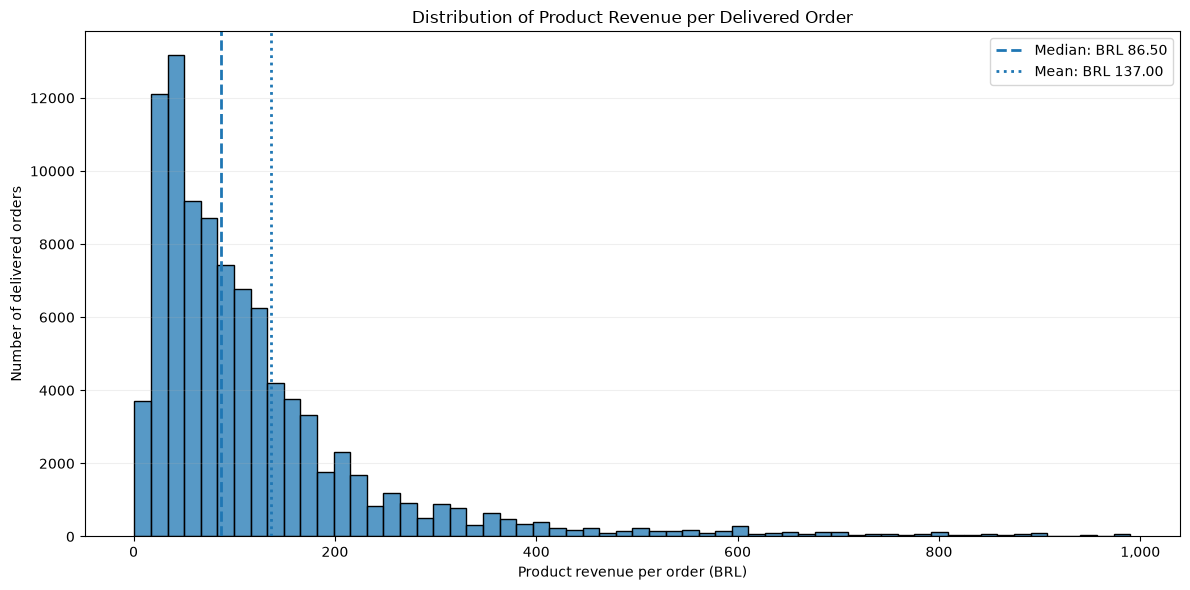

99th percentile display limit: 991.71
Orders displayed: 95,248
Orders excluded from chart display only: 963
Chart saved to: /Users/ivana/Projects/ecommerce-data-analysis/outputs/figures/order_value_distribution.png


In [24]:
from matplotlib.ticker import FuncFormatter


product_revenue_values = (
    delivered_orders_analysis["product_revenue"]
    .dropna()
)

revenue_display_limit = (
    product_revenue_values.quantile(0.99)
)

mean_product_revenue = (
    product_revenue_values.mean()
)

median_product_revenue = (
    product_revenue_values.median()
)


revenue_for_chart = (
    delivered_orders_analysis.loc[
        delivered_orders_analysis["product_revenue"]
        <= revenue_display_limit
    ]
)


fig, ax = plt.subplots(figsize=(12, 6))


sns.histplot(
    data=revenue_for_chart,
    x="product_revenue",
    bins=60,
    ax=ax,
)


ax.axvline(
    median_product_revenue,
    linestyle="--",
    linewidth=2,
    label=(
        f"Median: BRL "
        f"{median_product_revenue:,.2f}"
    ),
)

ax.axvline(
    mean_product_revenue,
    linestyle=":",
    linewidth=2,
    label=(
        f"Mean: BRL "
        f"{mean_product_revenue:,.2f}"
    ),
)


ax.set_title(
    "Distribution of Product Revenue per Delivered Order"
)

ax.set_xlabel(
    "Product revenue per order (BRL)"
)

ax.set_ylabel(
    "Number of delivered orders"
)


ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)


ax.legend()

ax.grid(
    axis="y",
    alpha=0.2,
)


fig.tight_layout()


figure_path = (
    FIGURE_DIR
    / "order_value_distribution.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "99th percentile display limit:",
    f"{revenue_display_limit:,.2f}",
)

print(
    "Orders displayed:",
    f"{len(revenue_for_chart):,}",
)

print(
    "Orders excluded from chart display only:",
    f"{(
        product_revenue_values
        > revenue_display_limit
    ).sum():,}",
)

print(
    "Chart saved to:",
    figure_path,
)

#### Interpretation

The distribution of product revenue per delivered order is strongly right-skewed. Most orders are concentrated in the lower revenue ranges, while progressively fewer orders appear as order value increases.

The median product revenue was BRL 86.50, meaning that half of delivered orders generated no more than this amount. The mean was higher at BRL 137.00 because a relatively small number of expensive orders pulled the arithmetic average upward.

The chart is limited to the 99th percentile, approximately BRL 991.71, to make the main distribution readable. Orders above this value remain included in the analytical dataset and are investigated separately as high-value observations.

### 3.2 Product Revenue Boxplot

The boxplot summarizes the central distribution of product revenue using the median, quartiles and IQR-based whiskers.

The horizontal axis is limited to the 95th percentile for readability. High-value orders beyond this display limit remain in the analytical dataset.High-value orders above this display limit remain in the dataset and are not removed from the analysis.

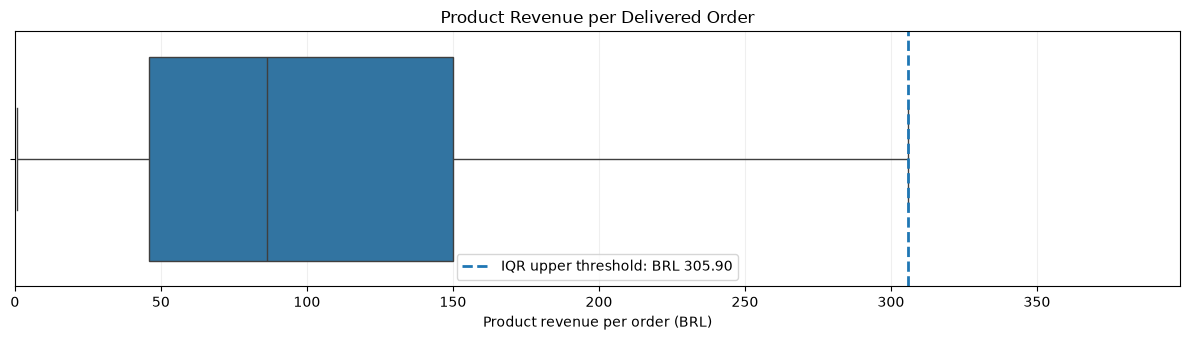

Q1: 45.90
Median: 86.50
Q3: 149.90
IQR upper threshold: 305.90
Chart saved to: /Users/ivana/Projects/ecommerce-data-analysis/outputs/figures/order_value_boxplot.png


In [25]:
fig, ax = plt.subplots(figsize=(12, 3.5))


sns.boxplot(
    data=delivered_orders_analysis,
    x="product_revenue",
    showfliers=False,
    ax=ax,
)


ax.axvline(
    product_revenue_upper_bound,
    linestyle="--",
    linewidth=2,
    label=(
        f"IQR upper threshold: BRL "
        f"{product_revenue_upper_bound:,.2f}"
    ),
)


boxplot_display_limit = (
    product_revenue_values.quantile(0.95)
)

ax.set_xlim(
    0,
    boxplot_display_limit,
)


ax.set_title(
    "Product Revenue per Delivered Order"
)

ax.set_xlabel(
    "Product revenue per order (BRL)"
)

ax.set_ylabel("")


ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)


ax.legend()

ax.grid(
    axis="x",
    alpha=0.2,
)


fig.tight_layout()


boxplot_path = (
    FIGURE_DIR
    / "order_value_boxplot.png"
)

fig.savefig(
    boxplot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Q1:",
    f"{product_revenue_q1:,.2f}",
)

print(
    "Median:",
    f"{product_revenue_values.median():,.2f}",
)

print(
    "Q3:",
    f"{product_revenue_q3:,.2f}",
)

print(
    "IQR upper threshold:",
    f"{product_revenue_upper_bound:,.2f}",
)

print(
    "Chart saved to:",
    boxplot_path,
)

#### Interpretation

The middle 50% of delivered orders generated between BRL 45.90 and BRL 149.90 in product revenue, with a median of BRL 86.50.

The IQR-based upper threshold was BRL 305.90. Orders above this amount were classified as statistical high-value outliers. These observations were retained because statistical outliers are not necessarily data errors; they may represent expensive products, large quantities, or other valid transactions.

The relatively compact central box and the presence of many values beyond the upper threshold reinforce the conclusion that product revenue is strongly right-skewed.

### 3.3 Business Contribution of High-Value Orders

Orders above the IQR upper threshold are compared with orders inside the typical value range.

This analysis determines whether high-value orders represent only unusual statistical observations or whether they also make a meaningful contribution to total revenue.

In [26]:
delivered_orders_analysis["order_value_segment"] = np.where(
    delivered_orders_analysis["product_revenue"]
    > product_revenue_upper_bound,
    "High-value order",
    "Typical-value order",
)

delivered_orders_analysis[
    "order_value_segment"
].value_counts()

order_value_segment
Typical-value order    88584
High-value order        7627
Name: count, dtype: int64

In [27]:
order_value_segment_summary = (
    delivered_orders_analysis.groupby(
        "order_value_segment",
        as_index=False,
    )
    .agg(
        order_count=("order_id", "count"),
        total_product_revenue=(
            "product_revenue",
            "sum",
        ),
        total_freight=("freight_value", "sum"),
        average_order_revenue=(
            "product_revenue",
            "mean",
        ),
        median_order_revenue=(
            "product_revenue",
            "median",
        ),
        average_item_count=("item_count", "mean"),
        reviewed_orders=(
            "avg_review_score",
            "count",
        ),
        average_review_score=(
            "avg_review_score",
            "mean",
        ),
        orders_with_delivery_data=(
            "delivery_days",
            "count",
        ),
        average_delivery_days=(
            "delivery_days",
            "mean",
        ),
    )
)


order_value_segment_summary["order_share_pct"] = (
    order_value_segment_summary["order_count"]
    .div(
        order_value_segment_summary[
            "order_count"
        ].sum()
    )
    .mul(100)
)


order_value_segment_summary["revenue_share_pct"] = (
    order_value_segment_summary[
        "total_product_revenue"
    ]
    .div(
        order_value_segment_summary[
            "total_product_revenue"
        ].sum()
    )
    .mul(100)
)


order_value_segment_summary["review_coverage_pct"] = (
    order_value_segment_summary["reviewed_orders"]
    .div(
        order_value_segment_summary["order_count"]
    )
    .mul(100)
)


display_columns = [
    "order_value_segment",
    "order_count",
    "order_share_pct",
    "total_product_revenue",
    "revenue_share_pct",
    "average_order_revenue",
    "median_order_revenue",
    "average_item_count",
    "average_review_score",
    "average_delivery_days",
    "review_coverage_pct",
]


order_value_segment_summary[
    display_columns
].round(2)

,order_value_segment,order_count,order_share_pct,total_product_revenue,revenue_share_pct,average_order_revenue,median_order_revenue,average_item_count,average_review_score,average_delivery_days,review_coverage_pct
0,High-value order,7627,7.93,4824497.24,36.6,632.56,478.3,1.40,4.04,13.95,99.15
1,Typical-value order,88584,92.07,8356529.89,63.4,94.33,79.0,1.12,4.17,12.35,99.35


In [28]:
high_value_item_profile = pd.DataFrame(
    {
        "metric": [
            "High-value orders",
            "High-value single-item orders",
            "High-value multi-item orders",
            "Single-item share of high-value orders",
            "Multi-item share of high-value orders",
        ],
        "value": [
            len(high_value_orders),
            int(
                (
                    high_value_orders["item_count"] == 1
                ).sum()
            ),
            int(
                (
                    high_value_orders["item_count"] > 1
                ).sum()
            ),
            (
                high_value_orders["item_count"]
                .eq(1)
                .mean()
                * 100
            ),
            (
                high_value_orders["item_count"]
                .gt(1)
                .mean()
                * 100
            ),
        ],
    }
)

high_value_item_profile.round(2)

,metric,value
0,High-value orders,7627.00
1,High-value single-item orders,6098.00
2,High-value multi-item orders,1529.00
3,Single-item share of high-value orders,79.95
4,Multi-item share of high-value orders,20.05


#### Interpretation

High-value orders represented only 7.93% of delivered orders but generated 36.60% of total product revenue. Their average product revenue was BRL 632.56, compared with BRL 94.33 for typical-value orders.

Approximately 79.95% of high-value orders contained only one item. This suggests that high order values were primarily associated with expensive individual products rather than large multi-item baskets.

High-value orders also had slightly weaker customer-experience results. Their average delivery time was 13.95 days, compared with 12.35 days for typical-value orders, while their average review score was 4.04 compared with 4.17.

Because this relatively small segment generates more than one-third of revenue, delivery performance and customer satisfaction for high-value orders should receive particular attention.

### 3.4 Order Share Versus Revenue Share

The following chart compares each order-value segment’s share of delivered orders with its share of total product revenue.

A large difference between these percentages indicates that a segment contributes disproportionately to revenue.

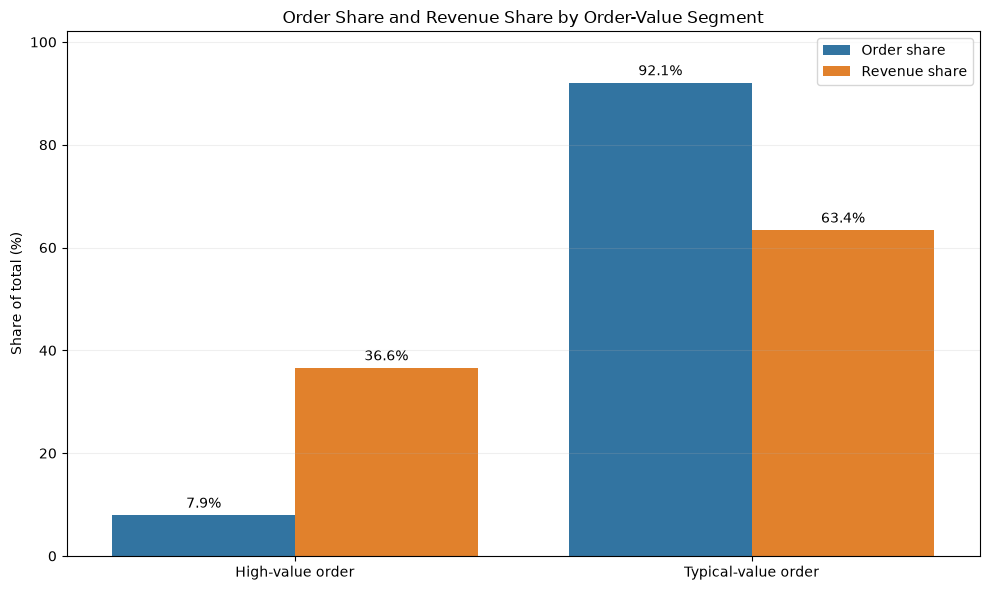

Chart saved to: /Users/ivana/Projects/ecommerce-data-analysis/outputs/figures/high_value_order_contribution.png


In [29]:
segment_share_chart_data = (
    order_value_segment_summary[
        [
            "order_value_segment",
            "order_share_pct",
            "revenue_share_pct",
        ]
    ]
    .rename(
        columns={
            "order_value_segment": "segment",
            "order_share_pct": "Order share",
            "revenue_share_pct": "Revenue share",
        }
    )
    .melt(
        id_vars="segment",
        var_name="metric",
        value_name="percentage",
    )
)


fig, ax = plt.subplots(figsize=(10, 6))


sns.barplot(
    data=segment_share_chart_data,
    x="segment",
    y="percentage",
    hue="metric",
    ax=ax,
)


ax.set_title(
    "Order Share and Revenue Share by Order-Value Segment"
)

ax.set_xlabel("")

ax.set_ylabel("Share of total (%)")


ax.set_ylim(
    0,
    segment_share_chart_data["percentage"].max() + 10,
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )


ax.legend(
    title="",
)

ax.grid(
    axis="y",
    alpha=0.2,
)


fig.tight_layout()


segment_chart_path = (
    FIGURE_DIR
    / "high_value_order_contribution.png"
)

fig.savefig(
    segment_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Chart saved to:",
    segment_chart_path,
)

#### Interpretation

High-value orders represented only 7.93% of delivered orders but generated 36.60% of total product revenue. This shows that a relatively small segment of orders contributes disproportionately to overall revenue.

Typical-value orders accounted for 92.07% of delivered orders and 63.40% of product revenue. Although they represent the majority of transactions, their revenue contribution is lower relative to their order volume.

Because high-value orders generate more than one-third of product revenue, protecting the customer experience for this segment may have an important financial impact. Their delivery performance, review scores, and product categories should therefore be monitored closely.

## 4. Customer Purchasing Behavior

The order-level analytical dataset is aggregated to one row per unique customer.

This customer-level table is used to evaluate purchase frequency, customer revenue, average order value, repeat purchasing behavior, customer activity periods, delivery performance, and review scores.

A customer is classified as a repeat customer when they placed more than one delivered order during the reporting period.

In [30]:
customer_summary = (
    delivered_orders_analysis.groupby(
        "customer_unique_id",
        as_index=False,
    )
    .agg(
        total_orders=("order_id", "count"),
        total_product_revenue=("product_revenue", "sum"),
        total_freight=("freight_value", "sum"),
        total_order_value=("total_order_value", "sum"),
        total_items=("item_count", "sum"),
        average_items_per_order=("item_count", "mean"),
        reviewed_orders=("avg_review_score", "count"),
        average_review_score=("avg_review_score", "mean"),
        orders_with_delivery_data=("delivery_days", "count"),
        average_delivery_days=("delivery_days", "mean"),
        first_purchase_date=(
            "order_purchase_timestamp",
            "min",
        ),
        last_purchase_date=(
            "order_purchase_timestamp",
            "max",
        ),
        primary_customer_state=(
            "customer_state",
            "first",
        ),
    )
)


customer_summary["average_order_revenue"] = (
    customer_summary["total_product_revenue"]
    / customer_summary["total_orders"]
)


customer_summary["average_total_order_value"] = (
    customer_summary["total_order_value"]
    / customer_summary["total_orders"]
)


customer_summary["purchase_span_days"] = (
    customer_summary["last_purchase_date"]
    - customer_summary["first_purchase_date"]
).dt.days


customer_summary["customer_type"] = np.where(
    customer_summary["total_orders"] == 1,
    "One-time customer",
    "Repeat customer",
)


customer_summary.head()

,customer_unique_id,total_orders,total_product_revenue,total_freight,total_order_value,total_items,average_items_per_order,reviewed_orders,average_review_score,orders_with_delivery_data,average_delivery_days,first_purchase_date,last_purchase_date,primary_customer_state,average_order_revenue,average_total_order_value,purchase_span_days,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,12.00,141.90,1.0,1.0,1,5.0,1,6.0,2018-05-10 10:56:27,2018-05-10 10:56:27,SP,129.90,141.90,0,One-time customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,8.29,27.19,1.0,1.0,1,4.0,1,3.0,2018-05-07 11:11:27,2018-05-07 11:11:27,SP,18.90,27.19,0,One-time customer
2,0000f46a3911fa3c0805444483337064,1,69.00,17.22,86.22,1.0,1.0,1,3.0,1,26.0,2017-03-10 21:05:03,2017-03-10 21:05:03,SC,69.00,86.22,0,One-time customer
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,17.63,43.62,1.0,1.0,1,4.0,1,20.0,2017-10-12 20:29:41,2017-10-12 20:29:41,PA,25.99,43.62,0,One-time customer
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,16.89,196.89,1.0,1.0,1,5.0,1,13.0,2017-11-14 19:45:42,2017-11-14 19:45:42,SP,180.00,196.89,0,One-time customer


In [31]:
customer_behavior_validation = pd.DataFrame(
    {
        "metric": [
            "Rows in customer-level table",
            "Unique customer IDs",
            "Duplicate customer IDs",
            "Delivered orders represented",
            "Delivered product revenue represented",
            "One-time customers",
            "Repeat customers",
            "Maximum delivered orders by one customer",
        ],
        "value": [
            len(customer_summary),
            customer_summary[
                "customer_unique_id"
            ].nunique(),
            int(
                customer_summary.duplicated(
                    subset=["customer_unique_id"]
                ).sum()
            ),
            int(
                customer_summary[
                    "total_orders"
                ].sum()
            ),
            customer_summary[
                "total_product_revenue"
            ].sum(),
            int(
                customer_summary[
                    "customer_type"
                ].eq("One-time customer")
                .sum()
            ),
            int(
                customer_summary[
                    "customer_type"
                ].eq("Repeat customer")
                .sum()
            ),
            int(
                customer_summary[
                    "total_orders"
                ].max()
            ),
        ],
    }
)

customer_behavior_validation

,metric,value
0,Rows in customer-level table,93104.00
1,Unique customer IDs,93104.00
2,Duplicate customer IDs,0.00
3,Delivered orders represented,96211.00
4,Delivered product revenue represented,13181027.13
5,One-time customers,90315.00
6,Repeat customers,2789.00
7,Maximum delivered orders by one customer,15.00


In [32]:
customer_type_summary = (
    customer_summary.groupby(
        "customer_type",
        as_index=False,
    )
    .agg(
        customer_count=(
            "customer_unique_id",
            "count",
        ),
        total_orders=(
            "total_orders",
            "sum",
        ),
        total_product_revenue=(
            "total_product_revenue",
            "sum",
        ),
        average_orders_per_customer=(
            "total_orders",
            "mean",
        ),
        average_revenue_per_customer=(
            "total_product_revenue",
            "mean",
        ),
        median_revenue_per_customer=(
            "total_product_revenue",
            "median",
        ),
        average_customer_order_revenue=(
            "average_order_revenue",
           "mean",
        ),
        average_items_per_order=(
            "average_items_per_order",
            "mean",
        ),
        average_customer_review_score=(
            "average_review_score",
            "mean",
        ),
        average_customer_delivery_days=(
            "average_delivery_days",
            "mean",
        ),
    )
)


customer_type_summary["customer_share_pct"] = (
    customer_type_summary["customer_count"]
    .div(
        customer_type_summary[
            "customer_count"
        ].sum()
    )
    .mul(100)
)


customer_type_summary["order_share_pct"] = (
    customer_type_summary["total_orders"]
    .div(
        customer_type_summary[
            "total_orders"
        ].sum()
    )
    .mul(100)
)


customer_type_summary["revenue_share_pct"] = (
    customer_type_summary[
        "total_product_revenue"
    ]
    .div(
        customer_type_summary[
            "total_product_revenue"
        ].sum()
    )
    .mul(100)
)


customer_type_display_columns = [
    "customer_type",
    "customer_count",
    "customer_share_pct",
    "total_orders",
    "order_share_pct",
    "total_product_revenue",
    "revenue_share_pct",
    "average_orders_per_customer",
    "average_revenue_per_customer",
    "median_revenue_per_customer",
    "average_customer_order_revenue",
    "average_customer_review_score",
    "average_customer_delivery_days",
]


customer_type_summary[
    customer_type_display_columns
].round(2)

,customer_type,customer_count,customer_share_pct,total_orders,order_share_pct,total_product_revenue,revenue_share_pct,average_orders_per_customer,average_revenue_per_customer,median_revenue_per_customer,average_customer_order_revenue,average_customer_review_score,average_customer_delivery_days
0,One-time customer,90315,97.0,90315,93.87,12455672.09,94.5,1.00,137.91,86.90,137.91,4.15,12.49
1,Repeat customer,2789,3.0,5896,6.13,725355.04,5.5,2.11,260.08,182.88,122.95,4.20,12.26


### Customer-Level Versus Order-Level Averages

The customer-level summary gives each customer equal weight. For example, a customer with two delivered orders has the same influence on the customer-level average as a customer with ten delivered orders.

This is appropriate when describing the typical customer. However, operational experience metrics such as review score and delivery time are also calculated at the order level so that every delivered order receives equal weight. The order-level results can then be reconciled with the completed SQL analysis.

In [33]:
customer_type_lookup = customer_summary[
    [
        "customer_unique_id",
        "customer_type",
    ]
].copy()


orders_by_customer_type = (
    delivered_orders_analysis.merge(
        customer_type_lookup,
        on="customer_unique_id",
        how="left",
        validate="many_to_one",
    )
)


customer_type_order_summary = (
    orders_by_customer_type.groupby(
        "customer_type",
        as_index=False,
    )
    .agg(
        total_orders=(
            "order_id",
            "count",
        ),
        total_product_revenue=(
            "product_revenue",
            "sum",
        ),
        average_order_revenue=(
            "product_revenue",
            "mean",
        ),
        median_order_revenue=(
            "product_revenue",
            "median",
        ),
        reviewed_orders=(
            "avg_review_score",
            "count",
        ),
        average_review_score=(
            "avg_review_score",
            "mean",
        ),
        orders_with_delivery_data=(
            "delivery_days",
            "count",
        ),
        average_delivery_days=(
            "delivery_days",
            "mean",
        ),
    )
)


customer_type_order_summary["order_share_pct"] = (
    customer_type_order_summary["total_orders"]
    .div(
        customer_type_order_summary[
            "total_orders"
        ].sum()
    )
    .mul(100)
)


customer_type_order_summary["revenue_share_pct"] = (
    customer_type_order_summary[
        "total_product_revenue"
    ]
    .div(
        customer_type_order_summary[
            "total_product_revenue"
        ].sum()
    )
    .mul(100)
)


customer_type_order_summary["review_coverage_pct"] = (
    customer_type_order_summary["reviewed_orders"]
    .div(
        customer_type_order_summary["total_orders"]
    )
    .mul(100)
)


customer_type_order_summary[
    [
        "customer_type",
        "total_orders",
        "order_share_pct",
        "total_product_revenue",
        "revenue_share_pct",
        "average_order_revenue",
        "median_order_revenue",
        "average_review_score",
        "average_delivery_days",
        "review_coverage_pct",
    ]
].round(2)

,customer_type,total_orders,order_share_pct,total_product_revenue,revenue_share_pct,average_order_revenue,median_order_revenue,average_review_score,average_delivery_days,review_coverage_pct
0,One-time customer,90315,93.87,12455672.09,94.5,137.91,86.9,4.15,12.49,99.35
1,Repeat customer,5896,6.13,725355.04,5.5,123.02,81.3,4.22,12.23,99.12


#### Interpretation

Repeat customers represented only 3.00% of unique customers but generated 6.13% of delivered orders and 5.50% of product revenue.

Their average revenue per customer was BRL 260.08, compared with BRL 137.91 for one-time customers. This indicates that repeat customers were more valuable at the customer level because they purchased more frequently.

However, the average repeat-customer order generated BRL 123.02, compared with BRL 137.91 for one-time-customer orders. Repeat customers therefore created more value through purchase frequency rather than through larger individual orders.

Repeat-customer orders also had slightly higher average review scores and slightly shorter delivery times, although these customer-experience differences were small.

### 4.1 Customer, Order and Revenue Contribution by Customer Type

The following chart compares each customer type’s share of unique customers, delivered orders, and product revenue.

This comparison shows whether repeat customers contribute more business activity and revenue than their small share of the customer base would suggest.

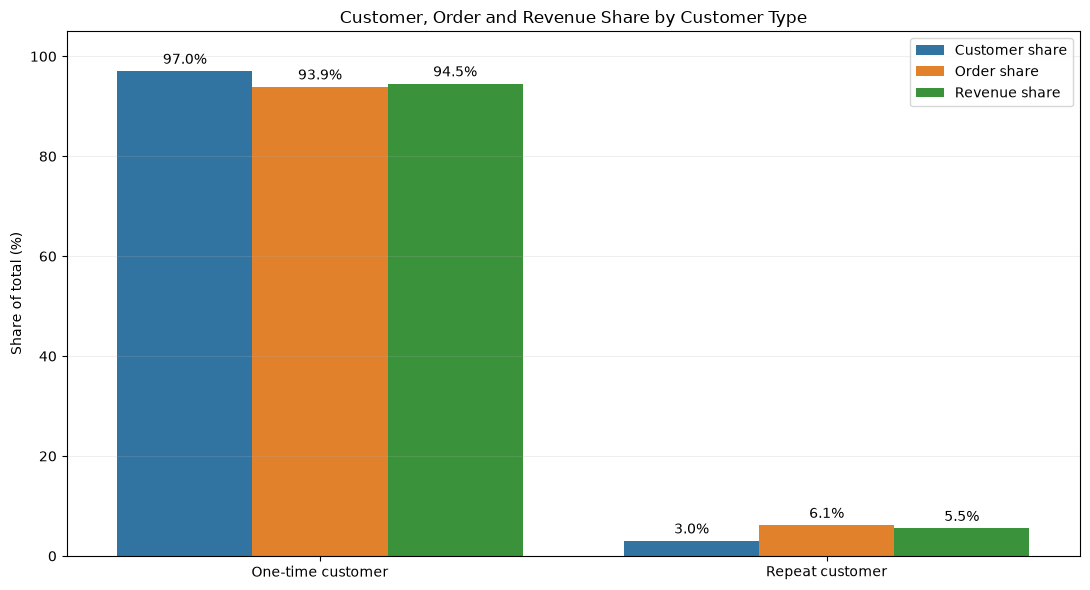

Chart saved to: /Users/ivana/Projects/ecommerce-data-analysis/outputs/figures/customer_type_contribution.png


In [34]:
customer_contribution_chart_data = (
    customer_type_summary[
        [
            "customer_type",
            "customer_share_pct",
            "order_share_pct",
            "revenue_share_pct",
        ]
    ]
    .rename(
        columns={
            "customer_type": "customer_type",
            "customer_share_pct": "Customer share",
            "order_share_pct": "Order share",
            "revenue_share_pct": "Revenue share",
        }
    )
    .melt(
        id_vars="customer_type",
        var_name="metric",
        value_name="percentage",
    )
)


fig, ax = plt.subplots(figsize=(11, 6))


sns.barplot(
    data=customer_contribution_chart_data,
    x="customer_type",
    y="percentage",
    hue="metric",
    ax=ax,
)


ax.set_title(
    "Customer, Order and Revenue Share by Customer Type"
)

ax.set_xlabel("")

ax.set_ylabel("Share of total (%)")


ax.set_ylim(
    0,
    customer_contribution_chart_data[
        "percentage"
    ].max() + 8,
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )


ax.legend(
    title="",
)

ax.grid(
    axis="y",
    alpha=0.2,
)


fig.tight_layout()


customer_contribution_chart_path = (
    FIGURE_DIR
    / "customer_type_contribution.png"
)

fig.savefig(
    customer_contribution_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Chart saved to:",
    customer_contribution_chart_path,
)

#### Interpretation

Repeat customers represented 3.00% of the customer base but generated 6.13% of delivered orders and 5.50% of product revenue.

Their order share was therefore approximately twice their customer share, confirming that repeat purchasing increases customer-level value. However, their revenue share was slightly below their order share because repeat-customer orders had a lower average product revenue than one-time-customer orders.

The very low repeat-customer rate indicates a significant customer-retention opportunity. Even a modest increase in repeat purchasing could improve total order volume without relying entirely on acquiring new customers.

### 4.2 Customer Revenue Concentration

Customers are ranked from highest to lowest according to their total product revenue during the reporting period.

The analysis calculates the percentage of total revenue and delivered orders generated by the highest-value 1%, 5%, 10%, and 20% of customers.

These groups are cumulative. For example, the top 10% includes the customers already contained in the top 1% and top 5%.

In [35]:
customer_revenue_ranking = (
    customer_summary[
        [
            "customer_unique_id",
            "customer_type",
            "total_orders",
            "total_product_revenue",
            "average_order_revenue",
            "average_review_score",
            "average_delivery_days",
        ]
    ]
    .sort_values(
        "total_product_revenue",
        ascending=False,
    )
    .reset_index(drop=True)
)


customer_revenue_ranking["customer_rank"] = (
    np.arange(
        1,
        len(customer_revenue_ranking) + 1,
    )
)


customer_revenue_ranking["customer_share_pct"] = (
    customer_revenue_ranking["customer_rank"]
    .div(len(customer_revenue_ranking))
    .mul(100)
)


customer_revenue_ranking["cumulative_revenue"] = (
    customer_revenue_ranking[
        "total_product_revenue"
    ].cumsum()
)


customer_revenue_ranking[
    "cumulative_revenue_share_pct"
] = (
    customer_revenue_ranking[
        "cumulative_revenue"
    ]
    .div(
        customer_revenue_ranking[
            "total_product_revenue"
        ].sum()
    )
    .mul(100)
)


customer_revenue_ranking.head(10)

,customer_unique_id,customer_type,total_orders,total_product_revenue,average_order_revenue,average_review_score,average_delivery_days,customer_rank,customer_share_pct,cumulative_revenue,cumulative_revenue_share_pct
0,0a0a92112bd4c708ca5fde585afaa872,One-time customer,1,13440.0,13440.0,1.0,18.0,1,0.001074,13440.0,0.101965
1,da122df9eeddfedc1dc1f5349a1a690c,Repeat customer,2,7388.0,3694.0,5.0,16.0,2,0.002148,20828.0,0.158015
2,763c8b1c9c68a0229c42c9fc6f662b93,One-time customer,1,7160.0,7160.0,1.0,11.0,3,0.003222,27988.0,0.212336
3,dc4802a71eae9be1dd28f5d788ceb526,One-time customer,1,6735.0,6735.0,5.0,19.0,4,0.004296,34723.0,0.263432
4,459bef486812aa25204be022145caa62,One-time customer,1,6729.0,6729.0,NaN,21.0,5,0.005370,41452.0,0.314482
5,ff4159b92c40ebe40454e3e6a7c35ed6,One-time customer,1,6499.0,6499.0,5.0,12.0,6,0.006444,47951.0,0.363788
6,4007669dec559734d6f53e029e360987,One-time customer,1,5934.6,5934.6,1.0,19.0,7,0.007518,53885.6,0.408812
7,eebb5dda148d3893cdaf5b5ca3040ccb,One-time customer,1,4690.0,4690.0,4.0,19.0,8,0.008593,58575.6,0.444393
8,48e1ac109decbb87765a3eade6854098,One-time customer,1,4590.0,4590.0,5.0,14.0,9,0.009667,63165.6,0.479216
9,a229eba70ec1c2abef51f04987deb7a5,One-time customer,1,4400.0,4400.0,5.0,5.0,10,0.010741,67565.6,0.512597


In [36]:
concentration_thresholds = [
    1,
    5,
    10,
    20,
]


total_customers = len(
    customer_revenue_ranking
)

total_customer_revenue = (
    customer_revenue_ranking[
        "total_product_revenue"
    ].sum()
)

total_customer_orders = (
    customer_revenue_ranking[
        "total_orders"
    ].sum()
)


customer_revenue_concentration = pd.DataFrame(
    [
        {
            "top_customer_pct": threshold,
            "customer_count": int(
                np.ceil(
                    total_customers
                    * threshold
                    / 100
                )
            ),
        }
        for threshold in concentration_thresholds
    ]
)


customer_revenue_concentration[
    "revenue_share_pct"
] = customer_revenue_concentration.apply(
    lambda row: (
        customer_revenue_ranking
        .head(int(row["customer_count"]))[
            "total_product_revenue"
        ]
        .sum()
        / total_customer_revenue
        * 100
    ),
    axis=1,
)


customer_revenue_concentration[
    "order_share_pct"
] = customer_revenue_concentration.apply(
    lambda row: (
        customer_revenue_ranking
        .head(int(row["customer_count"]))[
            "total_orders"
        ]
        .sum()
        / total_customer_orders
        * 100
    ),
    axis=1,
)


customer_revenue_concentration[
    "average_revenue_per_customer"
] = customer_revenue_concentration.apply(
    lambda row: (
        customer_revenue_ranking
        .head(int(row["customer_count"]))[
            "total_product_revenue"
        ]
        .mean()
    ),
    axis=1,
)


customer_revenue_concentration.round(2)

,top_customer_pct,customer_count,revenue_share_pct,order_share_pct,average_revenue_per_customer
0,1,932,11.48,1.05,1623.96
1,5,4656,29.14,5.41,824.96
2,10,9311,41.10,10.72,581.84
3,20,18621,56.62,21.09,400.76


In [37]:
top_customer_columns = [
    "customer_rank",
    "customer_unique_id",
    "customer_type",
    "total_orders",
    "total_product_revenue",
    "average_order_revenue",
    "average_review_score",
    "average_delivery_days",
]


customer_revenue_ranking[
    top_customer_columns
].head(10).round(2)

,customer_rank,customer_unique_id,customer_type,total_orders,total_product_revenue,average_order_revenue,average_review_score,average_delivery_days
0,1,0a0a92112bd4c708ca5fde585afaa872,One-time customer,1,13440.0,13440.0,1.0,18.0
1,2,da122df9eeddfedc1dc1f5349a1a690c,Repeat customer,2,7388.0,3694.0,5.0,16.0
2,3,763c8b1c9c68a0229c42c9fc6f662b93,One-time customer,1,7160.0,7160.0,1.0,11.0
3,4,dc4802a71eae9be1dd28f5d788ceb526,One-time customer,1,6735.0,6735.0,5.0,19.0
4,5,459bef486812aa25204be022145caa62,One-time customer,1,6729.0,6729.0,NaN,21.0
5,6,ff4159b92c40ebe40454e3e6a7c35ed6,One-time customer,1,6499.0,6499.0,5.0,12.0
6,7,4007669dec559734d6f53e029e360987,One-time customer,1,5934.6,5934.6,1.0,19.0
7,8,eebb5dda148d3893cdaf5b5ca3040ccb,One-time customer,1,4690.0,4690.0,4.0,19.0
8,9,48e1ac109decbb87765a3eade6854098,One-time customer,1,4590.0,4590.0,5.0,14.0
9,10,a229eba70ec1c2abef51f04987deb7a5,One-time customer,1,4400.0,4400.0,5.0,5.0


#### Interpretation

Customer revenue was moderately concentrated among the highest-value customers. The top 1% of customers generated 11.48% of product revenue, while the top 10% generated 41.10%. The top 20% of customers generated 56.62% of total product revenue.

The highest-value 10% of customers generated approximately four times the revenue share that would be expected if revenue were distributed evenly across customers.

However, most of the ten highest-revenue customers were one-time customers. This indicates that high customer value was often driven by a single expensive purchase rather than repeated purchasing.

The business should therefore distinguish between loyal repeat customers and high-value one-time customers. Retention campaigns aimed at converting high-value one-time customers into repeat customers may provide a valuable growth opportunity.

### 4.3 Customer Share Versus Revenue Share

The chart compares cumulative customer groups with the proportion of total product revenue they generated.

If revenue were distributed evenly, the top 10% of customers would generate approximately 10% of revenue. A substantially larger revenue share indicates customer-value concentration.

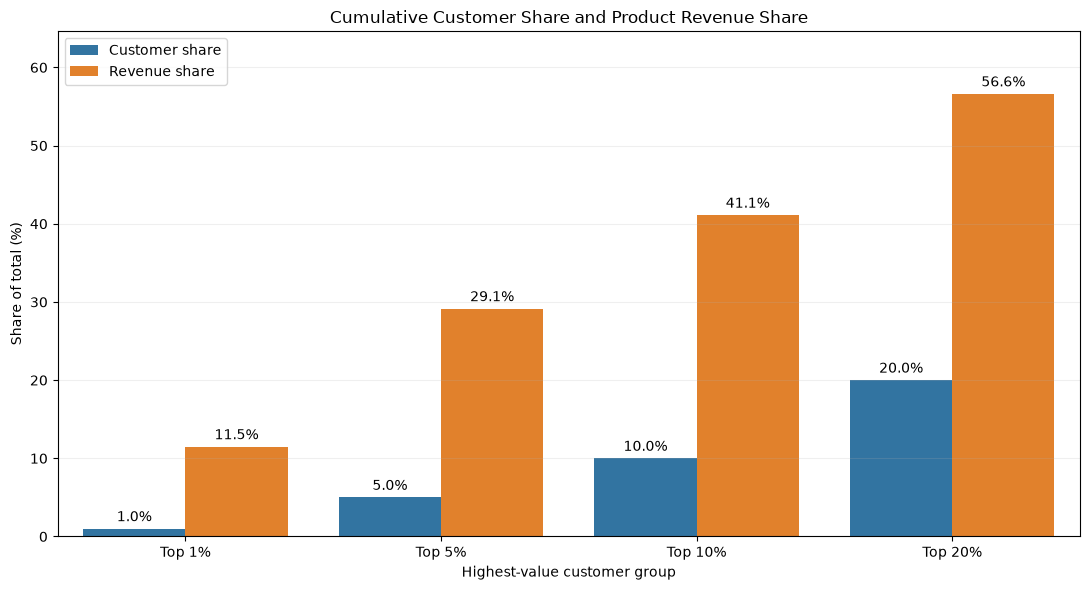

Chart saved to: /Users/ivana/Projects/ecommerce-data-analysis/outputs/figures/customer_revenue_concentration.png


In [38]:
customer_concentration_chart_data = (
    customer_revenue_concentration[
        [
            "top_customer_pct",
            "revenue_share_pct",
        ]
    ]
    .copy()
)


customer_concentration_chart_data[
    "customer_group"
] = (
    "Top "
    + customer_concentration_chart_data[
        "top_customer_pct"
    ].astype(str)
    + "%"
)


customer_concentration_chart_data[
    "customer_share_pct"
] = customer_concentration_chart_data[
    "top_customer_pct"
]


customer_concentration_chart_long = (
    customer_concentration_chart_data[
        [
            "customer_group",
            "customer_share_pct",
            "revenue_share_pct",
        ]
    ]
    .rename(
        columns={
            "customer_share_pct": "Customer share",
            "revenue_share_pct": "Revenue share",
        }
    )
    .melt(
        id_vars="customer_group",
        var_name="metric",
        value_name="percentage",
    )
)


fig, ax = plt.subplots(figsize=(11, 6))


sns.barplot(
    data=customer_concentration_chart_long,
    x="customer_group",
    y="percentage",
    hue="metric",
    ax=ax,
)


ax.set_title(
    "Cumulative Customer Share and Product Revenue Share"
)

ax.set_xlabel(
    "Highest-value customer group"
)

ax.set_ylabel(
    "Share of total (%)"
)


ax.set_ylim(
    0,
    customer_concentration_chart_long[
        "percentage"
    ].max() + 8,
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )


ax.legend(
    title="",
)

ax.grid(
    axis="y",
    alpha=0.2,
)


fig.tight_layout()


customer_concentration_chart_path = (
    FIGURE_DIR
    / "customer_revenue_concentration.png"
)

fig.savefig(
    customer_concentration_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Chart saved to:",
    customer_concentration_chart_path,
)

#### Interpretation

Revenue contribution increased much faster than customer share. The top 10% of customers represented 10% of the customer base but generated 41.10% of product revenue.

Similarly, the top 20% of customers generated 56.62% of revenue. This confirms that customer value is unevenly distributed and that higher-value customers have a disproportionate effect on business performance.

Because many of the highest-revenue customers placed only one order, a useful retention strategy would be to target high-value one-time customers with personalised second-purchase incentives.

## 5. Delivery Performance Analysis

This section evaluates how long delivered orders took to reach customers and whether they arrived before, on, or after the estimated delivery date.

Delivery duration is calculated in calendar days from the purchase date to the customer delivery date. Orders with missing or negative delivery durations are identified before the valid delivery records are analysed.

Because delivery times may contain unusually long delays, the analysis compares the mean, median, percentiles, and IQR-based outlier threshold.

In [39]:
delivery_data_validation = pd.DataFrame(
    {
        "metric": [
            "Delivered orders in primary dataset",
            "Orders missing actual delivery date",
            "Orders missing delivery duration",
            "Orders with negative delivery duration",
            "Orders with valid non-negative delivery duration",
            "Orders missing estimated delivery comparison",
        ],
        "value": [
            len(delivered_orders_analysis),
            int(
                delivered_orders_analysis[
                    "order_delivered_customer_date"
                ].isna().sum()
            ),
            int(
                delivered_orders_analysis[
                    "delivery_days"
                ].isna().sum()
            ),
            int(
                delivered_orders_analysis[
                    "delivery_days"
                ].lt(0).sum()
            ),
            int(
                delivered_orders_analysis[
                    "delivery_days"
                ].ge(0).sum()
            ),
            int(
                delivered_orders_analysis[
                    "delivery_vs_estimate_days"
                ].isna().sum()
            ),
        ],
    }
)

delivery_data_validation

,metric,value
0,Delivered orders in primary dataset,96211
1,Orders missing actual delivery date,8
2,Orders missing delivery duration,8
3,Orders with negative delivery duration,0
4,Orders with valid non-negative delivery duration,96203
5,Orders missing estimated delivery comparison,8


In [40]:
delivery_analysis = (
    delivered_orders_analysis.loc[
        delivered_orders_analysis["delivery_days"]
        .notna()
        & delivered_orders_analysis["delivery_days"]
        .ge(0)
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Orders available for delivery-time analysis:",
    f"{len(delivery_analysis):,}",
)

print(
    "Share of primary delivered orders:",
    f"{len(delivery_analysis) / len(delivered_orders_analysis):.2%}",
)

Orders available for delivery-time analysis: 96,203
Share of primary delivered orders: 99.99%


In [41]:
delivery_values = (
    delivery_analysis["delivery_days"]
    .astype("float64")
)

delivery_q1 = delivery_values.quantile(0.25)
delivery_median = delivery_values.quantile(0.50)
delivery_q3 = delivery_values.quantile(0.75)
delivery_iqr = delivery_q3 - delivery_q1

delivery_upper_outlier_bound = (
    delivery_q3
    + 1.5 * delivery_iqr
)

delivery_time_summary = pd.DataFrame(
    {
        "metric": [
            "Orders analysed",
            "Minimum delivery days",
            "Q1",
            "Median delivery days",
            "Mean delivery days",
            "Q3",
            "90th percentile",
            "95th percentile",
            "99th percentile",
            "Maximum delivery days",
            "Standard deviation",
            "IQR",
            "IQR upper outlier threshold",
            "Long-delivery outlier count",
            "Long-delivery outlier share",
        ],
        "value": [
            len(delivery_values),
            delivery_values.min(),
            delivery_q1,
            delivery_median,
            delivery_values.mean(),
            delivery_q3,
            delivery_values.quantile(0.90),
            delivery_values.quantile(0.95),
            delivery_values.quantile(0.99),
            delivery_values.max(),
            delivery_values.std(),
            delivery_iqr,
            delivery_upper_outlier_bound,
            int(
                (
                    delivery_values
                    > delivery_upper_outlier_bound
                ).sum()
            ),
            (
                delivery_values
                .gt(delivery_upper_outlier_bound)
                .mean()
                * 100
            ),
        ],
    }
)

delivery_time_summary.round(2)

,metric,value
0,Orders analysed,96203.00
1,Minimum delivery days,0.00
2,Q1,7.00
3,Median delivery days,10.00
4,Mean delivery days,12.48
5,Q3,16.00
6,90th percentile,23.00
7,95th percentile,29.00
8,99th percentile,46.00
9,Maximum delivery days,210.00


In [42]:
delivery_analysis["delivery_status"] = np.select(
    [
        delivery_analysis[
            "delivery_vs_estimate_days"
        ].lt(0),
        delivery_analysis[
            "delivery_vs_estimate_days"
        ].eq(0),
        delivery_analysis[
            "delivery_vs_estimate_days"
        ].gt(0),
    ],
    [
        "Delivered early",
        "Delivered on estimated date",
        "Delivered late",
    ],
    default="Missing estimate comparison",
)

delivery_status_summary = (
    delivery_analysis.groupby(
        "delivery_status",
        as_index=False,
    )
    .agg(
        order_count=("order_id", "count"),
        average_delivery_days=(
            "delivery_days",
            "mean",
        ),
        median_delivery_days=(
            "delivery_days",
            "median",
        ),
        average_days_vs_estimate=(
            "delivery_vs_estimate_days",
            "mean",
        ),
        average_review_score=(
            "avg_review_score",
            "mean",
        ),
    )
)

delivery_status_summary["order_share_pct"] = (
    delivery_status_summary["order_count"]
    .div(
        delivery_status_summary[
            "order_count"
        ].sum()
    )
    .mul(100)
)

delivery_status_summary[
    [
        "delivery_status",
        "order_count",
        "order_share_pct",
        "average_delivery_days",
        "median_delivery_days",
        "average_days_vs_estimate",
        "average_review_score",
    ]
].round(2)

,delivery_status,order_count,order_share_pct,average_delivery_days,median_delivery_days,average_days_vs_estimate,average_review_score
0,Delivered early,88381,91.87,10.8,10.0,-13.64,4.30
1,Delivered late,6531,6.79,33.9,31.0,10.62,2.27
2,Delivered on estimated date,1291,1.34,19.13,20.0,0.0,4.04


### 5.1 Delivery-Time Distribution

The histogram shows the distribution of delivery duration for successfully delivered orders with valid non-negative delivery times.

The visible range is limited to the 99th percentile so that the main delivery pattern remains readable. Orders above this limit remain in the analytical dataset and are investigated separately as unusually long deliveries.

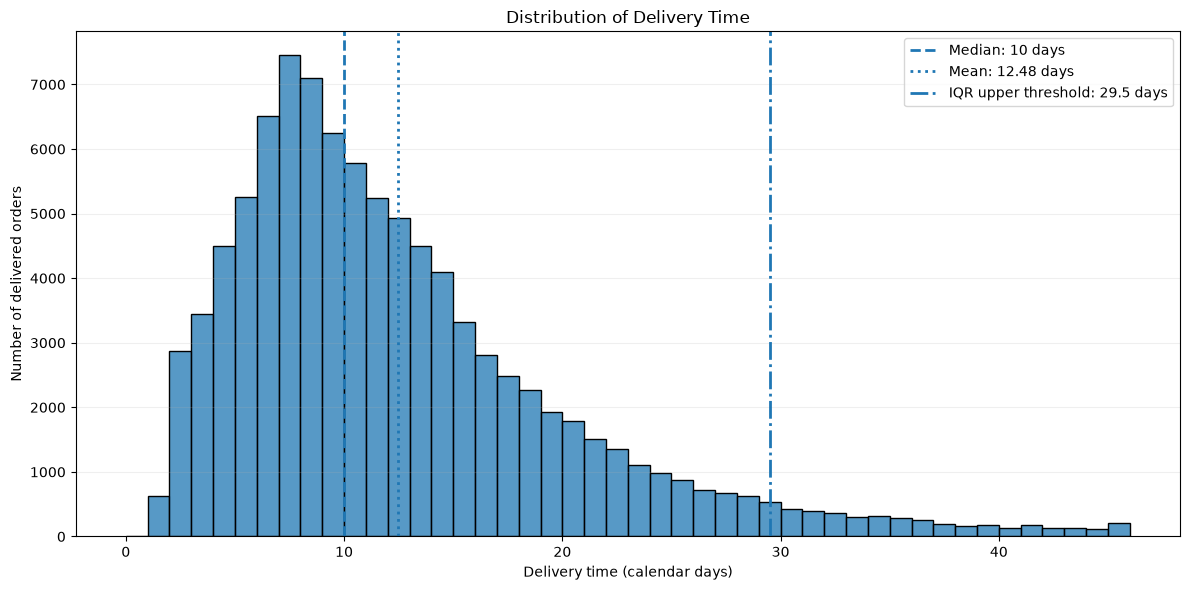

99th percentile display limit: 46 days
Orders displayed: 95,298
Orders excluded from chart display only: 905
Chart saved to: /Users/ivana/Projects/ecommerce-data-analysis/outputs/figures/delivery_time_distribution.png


In [43]:
delivery_display_limit = (
    delivery_values.quantile(0.99)
)

delivery_for_chart = (
    delivery_analysis.loc[
        delivery_analysis["delivery_days"]
        <= delivery_display_limit
    ]
)


fig, ax = plt.subplots(figsize=(12, 6))


sns.histplot(
    data=delivery_for_chart,
    x="delivery_days",
    bins=46,
    ax=ax,
)


ax.axvline(
    delivery_median,
    linestyle="--",
    linewidth=2,
    label=(
        f"Median: "
        f"{delivery_median:,.0f} days"
    ),
)


ax.axvline(
    delivery_values.mean(),
    linestyle=":",
    linewidth=2,
    label=(
        f"Mean: "
        f"{delivery_values.mean():,.2f} days"
    ),
)


ax.axvline(
    delivery_upper_outlier_bound,
    linestyle="-.",
    linewidth=2,
    label=(
        f"IQR upper threshold: "
        f"{delivery_upper_outlier_bound:,.1f} days"
    ),
)


ax.set_title(
    "Distribution of Delivery Time"
)

ax.set_xlabel(
    "Delivery time (calendar days)"
)

ax.set_ylabel(
    "Number of delivered orders"
)


ax.legend()

ax.grid(
    axis="y",
    alpha=0.2,
)


fig.tight_layout()


delivery_distribution_path = (
    FIGURE_DIR
    / "delivery_time_distribution.png"
)

fig.savefig(
    delivery_distribution_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "99th percentile display limit:",
    f"{delivery_display_limit:,.0f} days",
)

print(
    "Orders displayed:",
    f"{len(delivery_for_chart):,}",
)

print(
    "Orders excluded from chart display only:",
    f"{(
        delivery_values
        > delivery_display_limit
    ).sum():,}",
)

print(
    "Chart saved to:",
    delivery_distribution_path,
)

#### Interpretation

Delivery time was right-skewed. The median delivered order reached the customer in 10 days, while the mean was higher at 12.48 days because a smaller number of unusually long deliveries pulled the average upward.

Ninety percent of orders were delivered within 23 days, 95% within 29 days, and 99% within 46 days. The IQR-based upper threshold was 29.5 days, with 4.86% of valid deliveries classified as long-delivery statistical outliers.

The chart is limited to the 99th percentile for readability. Orders beyond this display limit remain in the analytical dataset.

### 5.2 Delivery Status Distribution

Orders are grouped according to whether they arrived before, on, or after the estimated delivery date.

This shows how frequently the company met its delivery estimates and identifies the proportion of orders exposed to late-delivery risk.

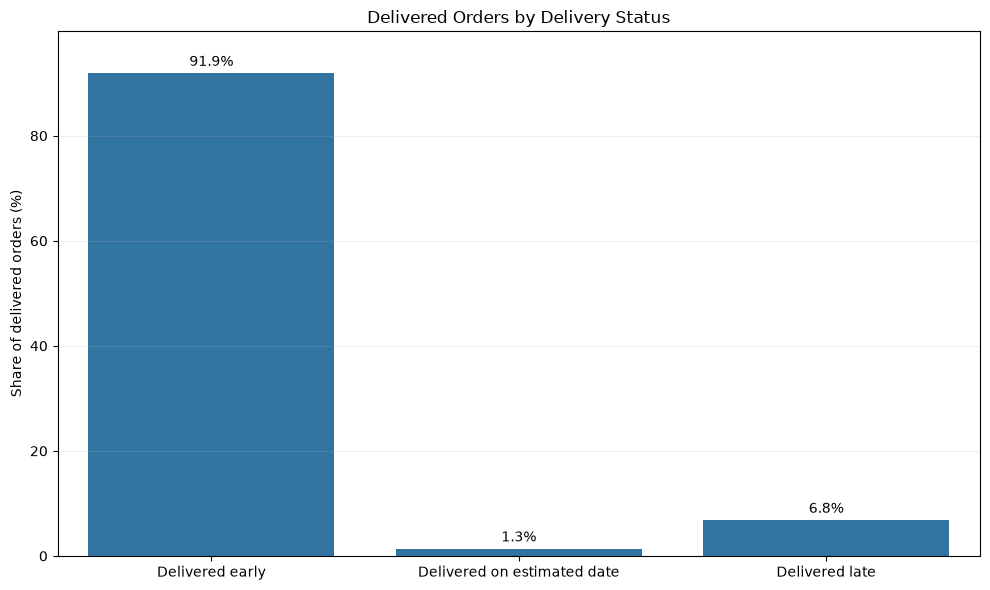

Chart saved to: /Users/ivana/Projects/ecommerce-data-analysis/outputs/figures/delivery_status_distribution.png


In [44]:
delivery_status_order = [
    "Delivered early",
    "Delivered on estimated date",
    "Delivered late",
]


delivery_status_chart_data = (
    delivery_status_summary.copy()
    .set_index("delivery_status")
    .reindex(delivery_status_order)
    .reset_index()
)


fig, ax = plt.subplots(figsize=(10, 6))


sns.barplot(
    data=delivery_status_chart_data,
    x="delivery_status",
    y="order_share_pct",
    ax=ax,
)


ax.set_title(
    "Delivered Orders by Delivery Status"
)

ax.set_xlabel("")

ax.set_ylabel(
    "Share of delivered orders (%)"
)


ax.set_ylim(
    0,
    delivery_status_chart_data[
        "order_share_pct"
    ].max() + 8,
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )


ax.grid(
    axis="y",
    alpha=0.2,
)


fig.tight_layout()


delivery_status_chart_path = (
    FIGURE_DIR
    / "delivery_status_distribution.png"
)

fig.savefig(
    delivery_status_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Chart saved to:",
    delivery_status_chart_path,
)

#### Interpretation

Most delivered orders, 91.87%, arrived before the estimated delivery date. A further 1.34% arrived on the estimated date, while 6.79% arrived late.

The large early-delivery share suggests that estimated delivery dates were generally conservative. However, late deliveries had substantially weaker customer-experience results: their average review score was 2.27, compared with 4.30 for early deliveries.

Although late deliveries represented a relatively small proportion of orders, their strong association with low review scores makes them an important operational priority.

## 6. Delivery Time and Customer Review Analysis

This section evaluates the relationship between delivery duration and customer satisfaction.

Only delivered orders with both a valid non-negative delivery duration and an available review score are included. Delivery times are grouped into the same business-readable ranges used in the SQL analysis so that the Python results can be reconciled with the PostgreSQL outputs.

In addition to average review scores, the analysis calculates the proportion of low reviews, defined as review scores of 1 or 2.

In [45]:
review_delivery_analysis = (
    delivery_analysis.loc[
        delivery_analysis["avg_review_score"].notna()
    ]
    .copy()
    .reset_index(drop=True)
)


review_delivery_validation = pd.DataFrame(
    {
        "metric": [
            "Orders with valid delivery duration",
            "Orders with valid delivery duration and review",
            "Orders excluded because review was missing",
            "Review coverage among valid deliveries",
            "Minimum review score",
            "Maximum review score",
        ],
        "value": [
            len(delivery_analysis),
            len(review_delivery_analysis),
            (
                len(delivery_analysis)
                - len(review_delivery_analysis)
            ),
            (
                len(review_delivery_analysis)
                / len(delivery_analysis)
                * 100
            ),
            review_delivery_analysis[
                "avg_review_score"
            ].min(),
            review_delivery_analysis[
                "avg_review_score"
            ].max(),
        ],
    }
)

review_delivery_validation.round(2)

,metric,value
0,Orders with valid delivery duration,96203.00
1,Orders with valid delivery duration and review,95560.00
2,Orders excluded because review was missing,643.00
3,Review coverage among valid deliveries,99.33
4,Minimum review score,1.00
5,Maximum review score,5.00


In [46]:
delivery_bucket_labels = [
    "0-3 days",
    "4-7 days",
    "8-14 days",
    "15-21 days",
    "22+ days",
]


review_delivery_analysis["delivery_time_bucket"] = pd.cut(
    review_delivery_analysis["delivery_days"].astype(float),
    bins=[
        -1,
        3,
        7,
        14,
        21,
        np.inf,
    ],
    labels=delivery_bucket_labels,
    include_lowest=True,
    right=True,
)


review_delivery_analysis["is_low_review"] = (
    review_delivery_analysis["avg_review_score"]
    .le(2)
)


review_delivery_analysis[
    [
        "order_id",
        "delivery_days",
        "delivery_time_bucket",
        "avg_review_score",
        "is_low_review",
    ]
].head()

,order_id,delivery_days,delivery_time_bucket,avg_review_score,is_low_review
0,e481f51cbdc54678b7cc49136f2d6af7,8,8-14 days,4.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,14,8-14 days,4.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,9,8-14 days,5.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,14,8-14 days,5.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,3,0-3 days,5.0,False


In [47]:
delivery_review_summary = (
    review_delivery_analysis.groupby(
        "delivery_time_bucket",
        observed=True,
        as_index=False,
    )
    .agg(
        total_orders=(
            "order_id",
            "count",
        ),
        average_delivery_days=(
            "delivery_days",
            "mean",
        ),
        average_review_score=(
            "avg_review_score",
            "mean",
        ),
        median_review_score=(
            "avg_review_score",
            "median",
        ),
        low_review_orders=(
            "is_low_review",
            "sum",
        ),
    )
)


delivery_review_summary["order_share_pct"] = (
    delivery_review_summary["total_orders"]
    .div(
        delivery_review_summary["total_orders"].sum()
    )
    .mul(100)
)


delivery_review_summary["low_review_rate_pct"] = (
    delivery_review_summary["low_review_orders"]
    .div(
        delivery_review_summary["total_orders"]
    )
    .mul(100)
)


delivery_review_summary[
    [
        "delivery_time_bucket",
        "total_orders",
        "order_share_pct",
        "average_delivery_days",
        "average_review_score",
        "median_review_score",
        "low_review_orders",
        "low_review_rate_pct",
    ]
].round(2)

,delivery_time_bucket,total_orders,order_share_pct,average_delivery_days,average_review_score,median_review_score,low_review_orders,low_review_rate_pct
0,0-3 days,6926,7.25,2.4,4.46,5.0,487,7.03
1,4-7 days,23590,24.69,5.71,4.40,5.0,1815,7.69
2,8-14 days,37695,39.45,10.65,4.30,5.0,3408,9.04
3,15-21 days,15995,16.74,17.5,4.12,5.0,1937,12.11
4,22+ days,11354,11.88,31.34,3.05,3.0,4545,40.03


In [48]:
sql_delivery_review_summary = pd.read_csv(
    SQL_EXPORT_DIR
    / "delivery_time_vs_review_score.csv"
)


python_delivery_review_for_check = (
    delivery_review_summary[
        [
            "delivery_time_bucket",
            "total_orders",
            "order_share_pct",
            "average_delivery_days",
            "average_review_score",
        ]
    ]
    .copy()
)


python_delivery_review_for_check[
    "delivery_time_bucket"
] = (
    python_delivery_review_for_check[
        "delivery_time_bucket"
    ].astype(str)
)


sql_delivery_review_for_check = (
    sql_delivery_review_summary.rename(
        columns={
            "delivery_time_bucket": "delivery_time_bucket",
            "avg_delivery_days": "sql_average_delivery_days",
            "avg_review_score": "sql_average_review_score",
            "total_orders": "sql_total_orders",
            "order_share_pct": "sql_order_share_pct",
        }
    )
)


delivery_review_reconciliation = (
    python_delivery_review_for_check.merge(
        sql_delivery_review_for_check,
        on="delivery_time_bucket",
        how="left",
        validate="one_to_one",
    )
)


delivery_review_reconciliation[
    "order_count_matches"
] = (
    delivery_review_reconciliation["total_orders"]
    ==
    delivery_review_reconciliation["sql_total_orders"]
)


delivery_review_reconciliation[
    "order_share_matches"
] = np.isclose(
    delivery_review_reconciliation["order_share_pct"],
    delivery_review_reconciliation["sql_order_share_pct"],
    atol=0.01,
)


delivery_review_reconciliation[
    "delivery_average_matches"
] = np.isclose(
    delivery_review_reconciliation["average_delivery_days"],
    delivery_review_reconciliation[
        "sql_average_delivery_days"
    ],
    atol=0.01,
)


delivery_review_reconciliation[
    "review_average_matches"
] = np.isclose(
    delivery_review_reconciliation["average_review_score"],
    delivery_review_reconciliation[
        "sql_average_review_score"
    ],
    atol=0.01,
)


delivery_review_reconciliation[
    [
        "delivery_time_bucket",
        "total_orders",
        "sql_total_orders",
        "order_count_matches",
        "order_share_matches",
        "delivery_average_matches",
        "review_average_matches",
    ]
]

,delivery_time_bucket,total_orders,sql_total_orders,order_count_matches,order_share_matches,delivery_average_matches,review_average_matches
0,0-3 days,6926,6926,True,True,True,True
1,4-7 days,23590,23590,True,True,True,True
2,8-14 days,37695,37695,True,True,True,True
3,15-21 days,15995,15995,True,True,True,True
4,22+ days,11354,11354,True,True,True,True


#### Interpretation

Python reproduced the SQL delivery-time results exactly across all five delivery buckets.

Customer satisfaction declined as delivery duration increased. Orders delivered within 0–3 days had an average review score of 4.46 and a low-review rate of 7.03%. For orders taking 22 days or more, the average review score fell to 3.05 and the low-review rate increased to 40.03%.

Low reviews were therefore approximately 5.7 times more common among orders delivered in 22 days or more than among orders delivered within 0–3 days.

The median review score remained 5 through the 15–21 day group but dropped to 3 for the 22+ day group. This suggests that customer dissatisfaction becomes particularly severe once delivery times reach the longest delivery category.

These results demonstrate a strong association between longer delivery times and weaker customer reviews. However, the analysis does not prove that delivery time was the only cause of low ratings, because product quality, incorrect items, and other service issues may also influence reviews.

### 6.1 Correlation Between Delivery Time and Review Score

Pearson and Spearman correlations are calculated to quantify the relationship between delivery duration and review score.

Pearson correlation measures linear association, while Spearman correlation measures whether review scores generally increase or decrease as delivery time changes. Spearman correlation is particularly relevant because delivery time is right-skewed and review scores are bounded between 1 and 5.

In [49]:
from scipy.stats import pearsonr, spearmanr


correlation_data = (
    review_delivery_analysis[
        [
            "delivery_days",
            "avg_review_score",
        ]
    ]
    .dropna()
    .astype(float)
)


pearson_result = pearsonr(
    correlation_data["delivery_days"],
    correlation_data["avg_review_score"],
)


spearman_result = spearmanr(
    correlation_data["delivery_days"],
    correlation_data["avg_review_score"],
)


delivery_review_correlation = pd.DataFrame(
    {
        "correlation_method": [
            "Pearson",
            "Spearman",
        ],
        "correlation_coefficient": [
            pearson_result.statistic,
            spearman_result.statistic,
        ],
        "p_value": [
            pearson_result.pvalue,
            spearman_result.pvalue,
        ],
        "observations": [
            len(correlation_data),
            len(correlation_data),
        ],
    }
)


delivery_review_correlation.round(4)

,correlation_method,correlation_coefficient,p_value,observations
0,Pearson,-0.3345,0.0,95560
1,Spearman,-0.2350,0.0,95560




#### Interpretation

Both correlation methods identified a statistically significant negative association between delivery time and customer review score.

The Pearson correlation was -0.3345, indicating a weak-to-moderate negative linear relationship. The Spearman correlation was -0.2350, indicating a weaker but still clear tendency for review scores to decline as delivery time increased.

The p-values were displayed as 0.0000 because they were extremely small, not because they were mathematically equal to zero. With 95,560 observations, the relationship is statistically detectable with very high confidence.

The coefficients do not imply that every long delivery produced a poor review or that delivery time was the only factor affecting satisfaction. Instead, they confirm an overall pattern in which longer deliveries were associated with lower customer ratings.

### 6.2 Average Review Score by Delivery Time

Average customer review scores are compared across ordered delivery-time buckets.

The buckets preserve the progression from the fastest to the slowest deliveries, making it possible to observe how customer satisfaction changes as delivery duration increases.

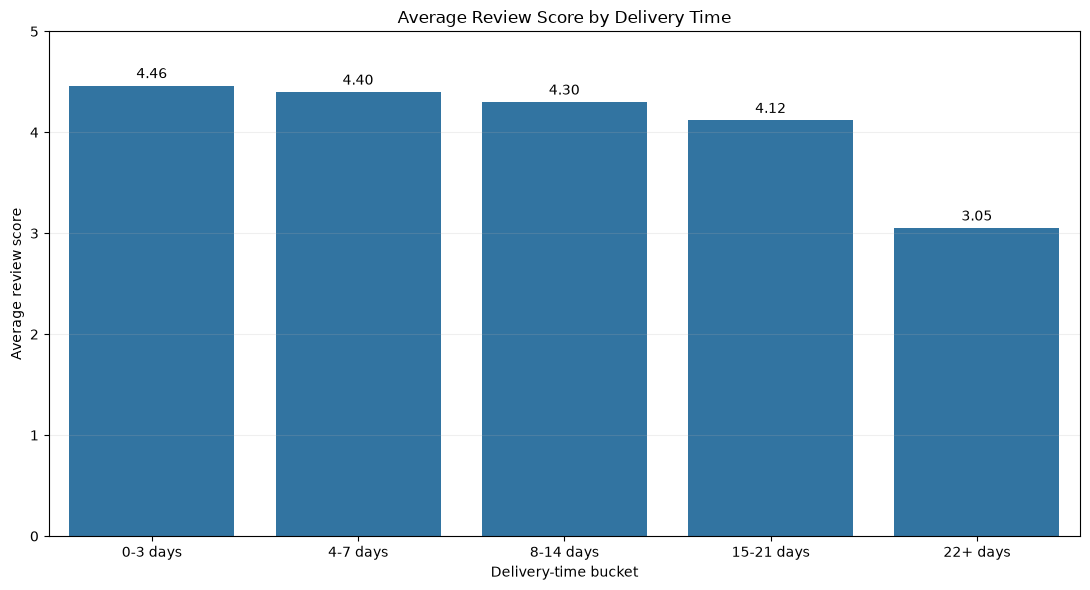

Chart saved to: /Users/ivana/Projects/ecommerce-data-analysis/outputs/figures/delivery_time_vs_review_score.png


In [50]:
delivery_bucket_order = [
    "0-3 days",
    "4-7 days",
    "8-14 days",
    "15-21 days",
    "22+ days",
]


delivery_review_chart_data = (
    delivery_review_summary.copy()
    .set_index("delivery_time_bucket")
    .reindex(delivery_bucket_order)
    .reset_index()
)


fig, ax = plt.subplots(figsize=(11, 6))


sns.barplot(
    data=delivery_review_chart_data,
    x="delivery_time_bucket",
    y="average_review_score",
    ax=ax,
)


ax.set_title(
    "Average Review Score by Delivery Time"
)

ax.set_xlabel(
    "Delivery-time bucket"
)

ax.set_ylabel(
    "Average review score"
)

ax.set_ylim(
    0,
    5,
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
    )


ax.grid(
    axis="y",
    alpha=0.2,
)


fig.tight_layout()


delivery_review_score_chart_path = (
    FIGURE_DIR
    / "delivery_time_vs_review_score.png"
)

fig.savefig(
    delivery_review_score_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Chart saved to:",
    delivery_review_score_chart_path,
)

#### Interpretation

Average review scores declined progressively as delivery time increased. Orders delivered within 0–3 days received an average review score of 4.46, compared with 3.05 for deliveries taking 22 days or more.

The decrease was relatively gradual through the first four delivery groups but became substantially larger in the 22+ day category. This suggests that customer satisfaction deteriorated most severely among the longest deliveries.

### 6.3 Low-Review Rate by Delivery Time

A low review is defined as a review score of 1 or 2.

The chart compares the percentage of low reviews within each delivery-time bucket. This makes it possible to assess how the risk of serious customer dissatisfaction changes with longer delivery durations.

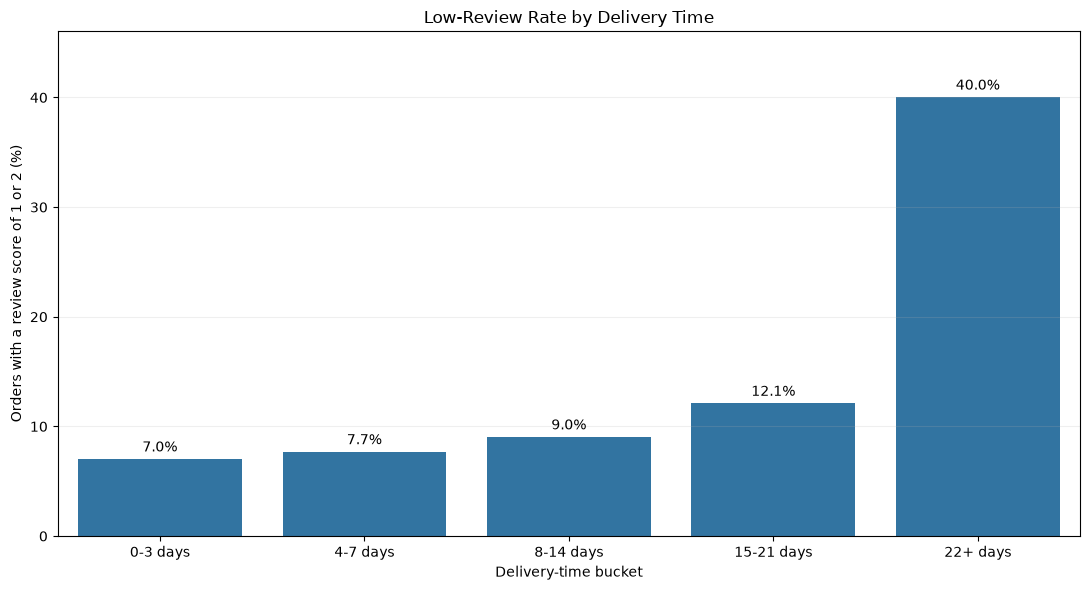

Chart saved to: /Users/ivana/Projects/ecommerce-data-analysis/outputs/figures/delivery_time_vs_low_review_rate.png


In [51]:
fig, ax = plt.subplots(figsize=(11, 6))


sns.barplot(
    data=delivery_review_chart_data,
    x="delivery_time_bucket",
    y="low_review_rate_pct",
    ax=ax,
)


ax.set_title(
    "Low-Review Rate by Delivery Time"
)

ax.set_xlabel(
    "Delivery-time bucket"
)

ax.set_ylabel(
    "Orders with a review score of 1 or 2 (%)"
)


ax.set_ylim(
    0,
    delivery_review_chart_data[
        "low_review_rate_pct"
    ].max() + 6,
)


for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )


ax.grid(
    axis="y",
    alpha=0.2,
)


fig.tight_layout()


delivery_low_review_chart_path = (
    FIGURE_DIR
    / "delivery_time_vs_low_review_rate.png"
)

fig.savefig(
    delivery_low_review_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Chart saved to:",
    delivery_low_review_chart_path,
)

#### Interpretation

The low-review rate increased from 7.03% for deliveries completed within 0–3 days to 40.03% for deliveries taking 22 days or more.

Low reviews were therefore approximately 5.7 times more common in the longest delivery group than in the fastest group.

The increase was gradual through the first four delivery buckets but accelerated sharply in the 22+ day category. Reducing the number of orders entering this longest-delivery group could therefore provide a meaningful improvement in customer satisfaction.

## 7. Geographic Analysis

This section evaluates sales and customer-experience performance by customer state.

Order-level metrics such as orders, revenue, average order value, delivery time, and review score are calculated from the delivered-order analytical dataset. Customer-level metrics, including unique customers and repeat-customer rates, are calculated from the customer summary dataset so that every customer is counted once.

A state may generate high revenue because it has a large customer base, high order frequency, high-value orders, or a combination of these factors. These drivers are therefore analysed separately.

In [52]:
geographic_data_validation = pd.DataFrame(
    {
        "metric": [
            "Delivered orders",
            "Orders missing customer state",
            "Distinct order-level customer states",
            "Unique customers",
            "Customers missing assigned state",
            "Distinct customer-level states",
        ],
        "value": [
            len(delivered_orders_analysis),
            int(
                delivered_orders_analysis[
                    "customer_state"
                ].isna().sum()
            ),
            int(
                delivered_orders_analysis[
                    "customer_state"
                ].nunique()
            ),
            len(customer_summary),
            int(
                customer_summary[
                    "primary_customer_state"
                ].isna().sum()
            ),
            int(
                customer_summary[
                    "primary_customer_state"
                ].nunique()
            ),
        ],
    }
)

geographic_data_validation

,metric,value
0,Delivered orders,96211
1,Orders missing customer state,0
2,Distinct order-level customer states,27
3,Unique customers,93104
4,Customers missing assigned state,0
5,Distinct customer-level states,27


In [53]:
[
    column
    for column in delivered_orders_analysis.columns
    if any(
        word in column.lower()
        for word in [
            "revenue",
            "price",
            "freight",
            "value",
        ]
    )
]

['product_revenue',
 'freight_value',
 'minimum_item_price',
 'maximum_item_price',
 'total_order_value',
 'order_value_segment']

In [54]:
state_order_summary = (
    delivered_orders_analysis.groupby(
        "customer_state",
        as_index=False,
    )
    .agg(
        total_orders=(
            "order_id",
            "count",
        ),
        total_product_revenue=(
            "product_revenue",
            "sum",
        ),
        average_order_revenue=(
            "product_revenue",
            "mean",
        ),
        median_order_revenue=(
            "product_revenue",
            "median",
        ),
        average_review_score=(
            "avg_review_score",
            "mean",
        ),
        average_delivery_days=(
            "delivery_days",
            "mean",
        ),
    )
)

state_order_summary.head()

,customer_state,total_orders,total_product_revenue,average_order_revenue,median_order_revenue,average_review_score,average_delivery_days
0,AC,80,15930.97,199.137125,119.45,4.087500,21.0
1,AL,396,78805.73,199.004369,107.35,3.852417,24.479798
2,AM,145,22155.84,152.798897,89.90,4.243056,26.358621
3,AP,67,13374.81,199.624030,109.90,4.242424,27.179104
4,BA,3253,493339.26,151.656705,93.50,3.929634,19.276975


In [55]:
state_customer_summary = (
    customer_summary.groupby(
        "primary_customer_state",
        as_index=False,
    )
    .agg(
        unique_customers=(
            "customer_unique_id",
            "count",
        ),
        repeat_customers=(
            "customer_type",
            lambda values: (
                values
                .eq("Repeat customer")
                .sum()
            ),
        ),
    )
    .rename(
        columns={
            "primary_customer_state": "customer_state",
        }
    )
)


state_customer_summary[
    "repeat_customer_rate_pct"
] = (
    state_customer_summary[
        "repeat_customers"
    ]
    .div(
        state_customer_summary[
            "unique_customers"
        ]
    )
    .mul(100)
)

In [56]:
state_geographic_summary = (
    state_order_summary.merge(
        state_customer_summary,
        on="customer_state",
        how="left",
        validate="one_to_one",
    )
)

In [57]:
state_geographic_summary[
    "order_share_pct"
] = (
    state_geographic_summary["total_orders"]
    .div(
        state_geographic_summary[
            "total_orders"
        ].sum()
    )
    .mul(100)
)


state_geographic_summary[
    "revenue_share_pct"
] = (
    state_geographic_summary[
        "total_product_revenue"
    ]
    .div(
        state_geographic_summary[
            "total_product_revenue"
        ].sum()
    )
    .mul(100)
)


state_geographic_summary[
    "customer_share_pct"
] = (
    state_geographic_summary[
        "unique_customers"
    ]
    .div(
        state_geographic_summary[
            "unique_customers"
        ].sum()
    )
    .mul(100)
)


state_geographic_summary[
    "orders_per_customer"
] = (
    state_geographic_summary[
        "total_orders"
    ]
    .div(
        state_geographic_summary[
            "unique_customers"
        ]
    )
)


state_geographic_summary = (
    state_geographic_summary.sort_values(
        "total_product_revenue",
        ascending=False,
    )
    .reset_index(drop=True)
)


state_geographic_summary.round(2)

,customer_state,total_orders,total_product_revenue,average_order_revenue,median_order_revenue,average_review_score,average_delivery_days,unique_customers,repeat_customers,repeat_customer_rate_pct,order_share_pct,revenue_share_pct,customer_share_pct,orders_per_customer
0,SP,40406,5055587.13,125.12,79.50,4.25,8.68,39060,1221,3.13,42.00,38.36,41.95,1.03
1,RJ,12310,1751433.85,142.28,89.99,3.97,15.22,11875,387,3.26,12.79,13.29,12.75,1.04
2,MG,11319,1548206.88,136.78,89.90,4.19,11.92,10964,319,2.91,11.76,11.75,11.78,1.03
3,RS,5328,726373.92,136.33,89.00,4.19,15.24,5150,158,3.07,5.54,5.51,5.53,1.03
4,PR,4903,664048.00,135.44,84.99,4.24,11.92,4749,140,2.95,5.10,5.04,5.10,1.03
5,SC,3537,504774.07,142.71,89.90,4.13,14.89,3436,91,2.65,3.68,3.83,3.69,1.03
6,BA,3253,493339.26,151.66,93.50,3.93,19.28,3155,90,2.85,3.38,3.74,3.39,1.03
7,DF,2074,295454.64,142.46,88.44,4.14,12.87,2011,59,2.93,2.16,2.24,2.16,1.03
8,GO,1950,281932.21,144.58,90.00,4.10,15.54,1888,58,3.07,2.03,2.14,2.03,1.03
9,ES,1992,267783.66,134.43,89.00,4.08,15.71,1925,57,2.96,2.07,2.03,2.07,1.03


In [58]:
geographic_summary_reconciliation = pd.DataFrame(
    {
        "metric": [
            "State rows",
            "Orders in state summary",
            "Expected delivered orders",
            "Order totals match",
            "Revenue in state summary",
            "Expected delivered revenue",
            "Revenue totals match",
            "Customers in state summary",
            "Expected unique customers",
            "Customer totals match",
            "Repeat customers in state summary",
            "Expected repeat customers",
            "Repeat-customer totals match",
            "Order share total",
            "Revenue share total",
            "Customer share total",
        ],
        "value": [
            len(state_geographic_summary),

            state_geographic_summary[
                "total_orders"
            ].sum(),

            len(delivered_orders_analysis),

            (
                state_geographic_summary[
                    "total_orders"
                ].sum()
                ==
                len(delivered_orders_analysis)
            ),

            state_geographic_summary[
                "total_product_revenue"
            ].sum(),

            delivered_orders_analysis[
                "product_revenue"
            ].sum(),

            np.isclose(
                state_geographic_summary[
                    "total_product_revenue"
                ].sum(),
                delivered_orders_analysis[
                    "product_revenue"
                ].sum(),
            ),

            state_geographic_summary[
                "unique_customers"
            ].sum(),

            len(customer_summary),

            (
                state_geographic_summary[
                    "unique_customers"
                ].sum()
                ==
                len(customer_summary)
            ),

            state_geographic_summary[
                "repeat_customers"
            ].sum(),

            int(
                customer_summary[
                    "customer_type"
                ]
                .eq("Repeat customer")
                .sum()
            ),

            (
                state_geographic_summary[
                    "repeat_customers"
                ].sum()
                ==
                customer_summary[
                    "customer_type"
                ]
                .eq("Repeat customer")
                .sum()
            ),

            state_geographic_summary[
                "order_share_pct"
            ].sum(),

            state_geographic_summary[
                "revenue_share_pct"
            ].sum(),

            state_geographic_summary[
                "customer_share_pct"
            ].sum(),
        ],
    }
)


geographic_summary_reconciliation

,metric,value
0,State rows,27
1,Orders in state summary,96211
2,Expected delivered orders,96211
3,Order totals match,True
4,Revenue in state summary,13181027.13
5,Expected delivered revenue,13181027.13
6,Revenue totals match,True
7,Customers in state summary,93104
8,Expected unique customers,93104
9,Customer totals match,True


In [59]:
state_display_columns = [
    "customer_state",
    "total_orders",
    "unique_customers",
    "total_product_revenue",
    "revenue_share_pct",
    "average_order_revenue",
    "median_order_revenue",
    "orders_per_customer",
    "repeat_customer_rate_pct",
    "average_review_score",
    "average_delivery_days",
]


state_geographic_summary[
    state_display_columns
].head(10).round(2)

,customer_state,total_orders,unique_customers,total_product_revenue,revenue_share_pct,average_order_revenue,median_order_revenue,orders_per_customer,repeat_customer_rate_pct,average_review_score,average_delivery_days
0,SP,40406,39060,5055587.13,38.36,125.12,79.50,1.03,3.13,4.25,8.68
1,RJ,12310,11875,1751433.85,13.29,142.28,89.99,1.04,3.26,3.97,15.22
2,MG,11319,10964,1548206.88,11.75,136.78,89.90,1.03,2.91,4.19,11.92
3,RS,5328,5150,726373.92,5.51,136.33,89.00,1.03,3.07,4.19,15.24
4,PR,4903,4749,664048.00,5.04,135.44,84.99,1.03,2.95,4.24,11.92
5,SC,3537,3436,504774.07,3.83,142.71,89.90,1.03,2.65,4.13,14.89
6,BA,3253,3155,493339.26,3.74,151.66,93.50,1.03,2.85,3.93,19.28
7,DF,2074,2011,295454.64,2.24,142.46,88.44,1.03,2.93,4.14,12.87
8,GO,1950,1888,281932.21,2.14,144.58,90.00,1.03,3.07,4.10,15.54
9,ES,1992,1925,267783.66,2.03,134.43,89.00,1.03,2.96,4.08,15.71


#### Interpretation

Geographic performance was strongly concentrated in Brazil's largest customer markets. São Paulo alone generated approximately 42% of delivered orders and 38.36% of product revenue.

São Paulo's revenue dominance was primarily volume-driven rather than order-value-driven. Its average order revenue was BRL 125.12, below the overall delivered-order average of approximately BRL 137.

The top three states—São Paulo, Rio de Janeiro, and Minas Gerais—generated 63.40% of product revenue. The top five states generated 73.95%, demonstrating substantial geographic revenue concentration.

Some smaller markets had higher average order values. Bahia, for example, generated an average of BRL 151.66 per order, but its much lower order volume limited its total revenue contribution.

Customer-experience performance also differed geographically. São Paulo combined the shortest average delivery time among the leading states with one of the highest average review scores, while states with longer average delivery times, including Bahia and Rio de Janeiro, generally received weaker reviews.

### 7.1 Customer State Assignment Validation

Unique customers may appear under different customer IDs and delivery addresses across multiple orders. The analysis therefore checks whether any unique customer placed delivered orders in more than one state.

Customer-level geographic metrics use the first observed state as the assigned customer state. The number of customers with purchases across multiple states is reviewed to assess the potential effect of this rule.

In [60]:
customer_state_counts = (
    delivered_orders_analysis.groupby(
        "customer_unique_id"
    )["customer_state"]
    .nunique()
)


customer_state_assignment_validation = pd.DataFrame(
    {
        "metric": [
            "Unique customers analysed",
            "Customers observed in one state",
            "Customers observed in multiple states",
            "Multi-state customer share",
            "Maximum states observed for one customer",
        ],
        "value": [
            len(customer_state_counts),

            int(
                customer_state_counts.eq(1).sum()
            ),

            int(
                customer_state_counts.gt(1).sum()
            ),

            (
                customer_state_counts.gt(1).mean()
                * 100
            ),

            int(
                customer_state_counts.max()
            ),
        ],
    }
)


customer_state_assignment_validation.round(4)

,metric,value
0,Unique customers analysed,93104.0000
1,Customers observed in one state,93068.0000
2,Customers observed in multiple states,36.0000
3,Multi-state customer share,0.0387
4,Maximum states observed for one customer,3.0000


#### Customer State Assignment Interpretation

Of the 93,104 unique customers analysed, only 36 customers were observed placing delivered orders in more than one state. This represented 0.0387% of the customer base.

Because 99.96% of customers were associated with only one state, assigning customers to their first observed state has a negligible effect on the customer-level geographic metrics.

Order-level geographic metrics are unaffected by this assignment rule because every delivered order remains associated with its actual customer state.

In [61]:
multi_state_customer_ids = (
    customer_state_counts.loc[
        customer_state_counts.gt(1)
    ]
    .index
)


multi_state_customer_examples = (
    delivered_orders_analysis.loc[
        delivered_orders_analysis[
            "customer_unique_id"
        ].isin(multi_state_customer_ids),
        [
            "customer_unique_id",
            "customer_state",
            "order_id",
            "order_purchase_timestamp",
        ],
    ]
    .sort_values(
        [
            "customer_unique_id",
            "order_purchase_timestamp",
        ]
    )
)


multi_state_customer_examples.head(20)

,customer_unique_id,customer_state,order_id,order_purchase_timestamp
40711,1f90117a847636892e3c5bf569f2ac68,PR,8d0584fef2164e00c8eb23abbdd87ef7,2017-08-13 20:03:35
84927,1f90117a847636892e3c5bf569f2ac68,SC,00c42b1633c1b2fa4e937bf312466561,2018-01-13 13:52:54
62724,2410195f6521688005612363835a2671,RS,dd4cb06a82daaa4a3853003208a89799,2017-09-06 21:55:50
6007,2410195f6521688005612363835a2671,SP,9dbaf3879dfddfc43171aaf9a9c0a82a,2017-09-06 22:07:43
53511,2c45ab66a3dae52960147e76a35740ff,MS,73c21d26eefa3d24be02a149b9e69017,2017-12-18 12:06:57
32784,2c45ab66a3dae52960147e76a35740ff,RS,b7d132ccaa4a7e53c9fb25ff9979fc35,2018-08-02 12:05:57
55819,2c6a91479a7dc00d8c9d650d8dee88ca,PR,a009ada42a46d83328c627c1ffc57f56,2017-11-06 21:44:01
35508,2c6a91479a7dc00d8c9d650d8dee88ca,SC,d7bf53fc0c235f32fd61f11e6cc99a2a,2018-01-16 21:39:46
4154,408aee96c75632a92e5079eee61da399,RJ,84705956de681a2d1420bd90d7667472,2017-01-31 14:38:27
55614,408aee96c75632a92e5079eee61da399,SP,d2b4a4076a8cb3ca3b43a1ee90b4a0e2,2018-06-21 21:02:24


#### Multi-State Customer Examples

The examples confirm that a small number of unique customers placed separate orders associated with different customer states.

The available data does not indicate whether these differences resulted from relocation, alternative delivery addresses, gift purchases, or data inconsistencies. Because only 36 customers, representing 0.0387% of the analysed customer base, were observed in multiple states, the first-observed-state assignment rule does not materially affect the geographic analysis.

### 7.2 Product Revenue by Customer State

The ten highest-revenue states are ranked by total product revenue from delivered orders.

Total revenue is influenced by both order volume and average order value. Therefore, a state with the highest total revenue does not necessarily have the highest average order value.

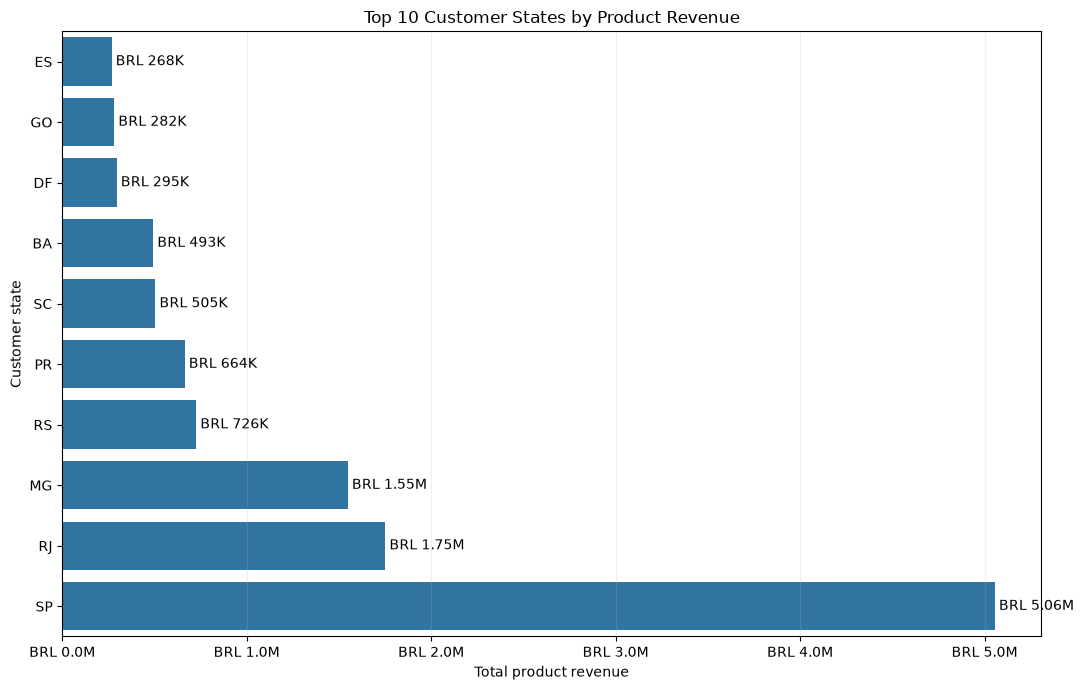

Chart saved to: /Users/ivana/Projects/ecommerce-data-analysis/outputs/figures/state_product_revenue_top10.png


In [62]:
from matplotlib.ticker import FuncFormatter


top_states_by_revenue = (
    state_geographic_summary
    .nlargest(
        10,
        "total_product_revenue",
    )
    .sort_values(
        "total_product_revenue",
        ascending=True,
    )
)


fig, ax = plt.subplots(figsize=(11, 7))


sns.barplot(
    data=top_states_by_revenue,
    x="total_product_revenue",
    y="customer_state",
    ax=ax,
)


ax.set_title(
    "Top 10 Customer States by Product Revenue"
)

ax.set_xlabel(
    "Total product revenue"
)

ax.set_ylabel(
    "Customer state"
)


ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: (
            f"BRL {value / 1_000_000:.1f}M"
        )
    )
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            (
                f"BRL {value / 1_000_000:.2f}M"
                if value >= 1_000_000
                else f"BRL {value / 1_000:.0f}K"
            )
            for value in container.datavalues
        ],
        padding=3,
    )


ax.grid(
    axis="x",
    alpha=0.2,
)


fig.tight_layout()


state_revenue_chart_path = (
    FIGURE_DIR
    / "state_product_revenue_top10.png"
)

fig.savefig(
    state_revenue_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Chart saved to:",
    state_revenue_chart_path,
)

#### Interpretation

São Paulo was the dominant customer market, generating BRL 5.06 million, or 38.36% of total product revenue.

Rio de Janeiro and Minas Gerais were the second- and third-largest markets. Together, São Paulo, Rio de Janeiro, and Minas Gerais generated 63.40% of product revenue.

São Paulo's position was primarily driven by its much larger order and customer volume rather than by high average order value. Its average order revenue of BRL 125.12 was below the overall delivered-order average of approximately BRL 137.

### 7.3 State Delivery Time and Review Performance

The relationship between average delivery time and average review score is compared across states with at least 1,000 delivered orders.

The minimum-order threshold reduces the influence of small states whose averages may be based on relatively few observations. Each point represents one state, not one individual order.

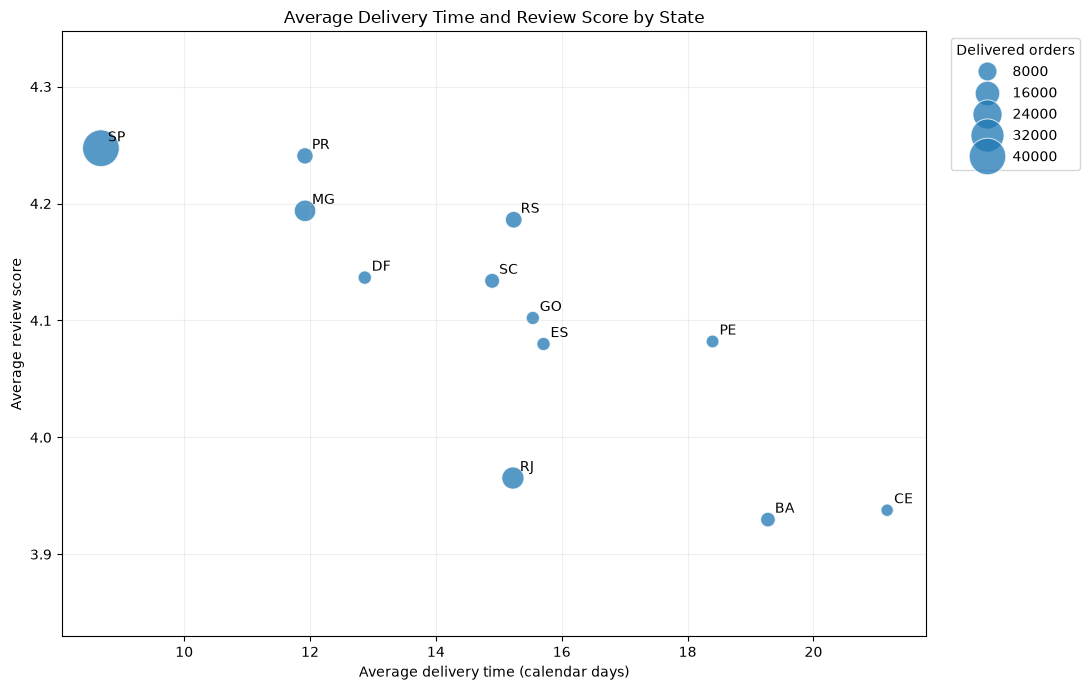

States displayed: 12
Chart saved to: /Users/ivana/Projects/ecommerce-data-analysis/outputs/figures/state_delivery_vs_review_score.png


In [63]:
state_experience_chart_data = (
    state_geographic_summary.loc[
        state_geographic_summary[
            "total_orders"
        ].ge(1_000)
    ]
    .copy()
)


fig, ax = plt.subplots(figsize=(11, 7))


sns.scatterplot(
    data=state_experience_chart_data,
    x="average_delivery_days",
    y="average_review_score",
    size="total_orders",
    sizes=(80, 700),
    alpha=0.75,
    ax=ax,
)


for _, row in state_experience_chart_data.iterrows():
    ax.annotate(
        row["customer_state"],
        (
            row["average_delivery_days"],
            row["average_review_score"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )


ax.set_title(
    "Average Delivery Time and Review Score by State"
)

ax.set_xlabel(
    "Average delivery time (calendar days)"
)

ax.set_ylabel(
    "Average review score"
)


ax.set_ylim(
    state_experience_chart_data[
        "average_review_score"
    ].min() - 0.1,
    state_experience_chart_data[
        "average_review_score"
    ].max() + 0.1,
)


ax.grid(
    alpha=0.2,
)


ax.legend(
    title="Delivered orders",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)


fig.tight_layout()


state_experience_chart_path = (
    FIGURE_DIR
    / "state_delivery_vs_review_score.png"
)

fig.savefig(
    state_experience_chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "States displayed:",
    len(state_experience_chart_data),
)

print(
    "Chart saved to:",
    state_experience_chart_path,
)

#### Interpretation

States with longer average delivery times generally also showed weaker average review scores.

São Paulo combined the shortest average delivery time among the major states, at 8.68 days, with an average review score of 4.25. In contrast, Bahia had an average delivery time of 19.28 days and an average review score of 3.93.

Rio de Janeiro also showed relatively long delivery times and weaker review performance despite being the second-largest revenue market. This suggests that improvements in delivery performance in large states such as Rio de Janeiro could affect a substantial number of customers.

This chart is based on state-level averages and should not be interpreted as proof that delivery time alone caused differences in review scores.

## 8. Final Outlier and Data-Quality Review

This section consolidates the order-value and delivery-time outlier checks performed earlier in the analysis.

An observation is classified as a statistical outlier when it exceeds the upper IQR threshold for its measure. Statistical outliers are not automatically treated as errors. They are retained unless there is evidence that the values are impossible, duplicated, or incorrectly recorded.

The analysis also examines whether high-value orders overlap with unusually long deliveries and whether these groups show weaker customer-review outcomes.

In [64]:
product_revenue_values = (
    delivered_orders_analysis[
        "product_revenue"
    ]
    .dropna()
    .astype(float)
)


product_revenue_q1 = (
    product_revenue_values.quantile(0.25)
)

product_revenue_q3 = (
    product_revenue_values.quantile(0.75)
)

product_revenue_iqr = (
    product_revenue_q3
    - product_revenue_q1
)

product_revenue_upper_bound = (
    product_revenue_q3
    + 1.5 * product_revenue_iqr
)


delivery_outlier_values = (
    delivered_orders_analysis[
        "delivery_days"
    ]
    .dropna()
    .loc[
        lambda values: values.ge(0)
    ]
    .astype(float)
)


delivery_outlier_q1 = (
    delivery_outlier_values.quantile(0.25)
)

delivery_outlier_q3 = (
    delivery_outlier_values.quantile(0.75)
)

delivery_outlier_iqr = (
    delivery_outlier_q3
    - delivery_outlier_q1
)

delivery_outlier_upper_bound = (
    delivery_outlier_q3
    + 1.5 * delivery_outlier_iqr
)

In [65]:
final_outlier_threshold_summary = pd.DataFrame(
    {
        "measure": [
            "Product revenue per order",
            "Delivery time",
        ],
        "unit": [
            "BRL",
            "Calendar days",
        ],
        "q1": [
            product_revenue_q1,
            delivery_outlier_q1,
        ],
        "q3": [
            product_revenue_q3,
            delivery_outlier_q3,
        ],
        "iqr": [
            product_revenue_iqr,
            delivery_outlier_iqr,
        ],
        "upper_outlier_threshold": [
            product_revenue_upper_bound,
            delivery_outlier_upper_bound,
        ],
        "outlier_count": [
            int(
                product_revenue_values
                .gt(product_revenue_upper_bound)
                .sum()
            ),
            int(
                delivery_outlier_values
                .gt(delivery_outlier_upper_bound)
                .sum()
            ),
        ],
        "outlier_share_pct": [
            (
                product_revenue_values
                .gt(product_revenue_upper_bound)
                .mean()
                * 100
            ),
            (
                delivery_outlier_values
                .gt(delivery_outlier_upper_bound)
                .mean()
                * 100
            ),
        ],
        "maximum_value": [
            product_revenue_values.max(),
            delivery_outlier_values.max(),
        ],
    }
)


final_outlier_threshold_summary.round(2)

,measure,unit,q1,q3,iqr,upper_outlier_threshold,outlier_count,outlier_share_pct,maximum_value
0,Product revenue per order,BRL,45.9,149.9,104.0,305.9,7627,7.93,13440.0
1,Delivery time,Calendar days,7.0,16.0,9.0,29.5,4679,4.86,210.0


In [66]:
outlier_analysis = (
    delivered_orders_analysis.copy()
)


outlier_analysis[
    "is_high_value_outlier"
] = (
    outlier_analysis[
        "product_revenue"
    ]
    .gt(product_revenue_upper_bound)
    .fillna(False)
    .astype(bool)
)


outlier_analysis[
    "is_long_delivery_outlier"
] = (
    outlier_analysis[
        "delivery_days"
    ]
    .gt(delivery_outlier_upper_bound)
    .fillna(False)
    .astype(bool)
)


outlier_analysis[
    "has_review"
] = (
    outlier_analysis[
        "avg_review_score"
    ]
    .notna()
)


outlier_analysis[
    "is_low_review"
] = (
    outlier_analysis[
        "avg_review_score"
    ]
    .le(2)
    .fillna(False)
    .astype(bool)
)


outlier_analysis[
    [
        "is_high_value_outlier",
        "is_long_delivery_outlier",
        "has_review",
        "is_low_review",
    ]
].dtypes

is_high_value_outlier       bool
is_long_delivery_outlier    bool
has_review                  bool
is_low_review               bool
dtype: object

In [67]:
high_value_flag = (
    outlier_analysis[
        "is_high_value_outlier"
    ]
    .to_numpy(dtype=bool)
)


long_delivery_flag = (
    outlier_analysis[
        "is_long_delivery_outlier"
    ]
    .to_numpy(dtype=bool)
)


outlier_analysis[
    "outlier_segment"
] = np.select(
    [
        high_value_flag
        & long_delivery_flag,

        high_value_flag,

        long_delivery_flag,
    ],
    [
        "High-value and long-delivery",
        "High-value only",
        "Long-delivery only",
    ],
    default="Neither",
)


outlier_analysis[
    "outlier_segment"
].value_counts()

outlier_segment
Neither                         84440
High-value only                  7092
Long-delivery only               4144
High-value and long-delivery      535
Name: count, dtype: int64

In [68]:
outlier_segment_summary = (
    outlier_analysis.groupby(
        "outlier_segment",
        as_index=False,
    )
    .agg(
        total_orders=(
            "order_id",
            "count",
        ),
        total_product_revenue=(
            "product_revenue",
            "sum",
        ),
        average_order_revenue=(
            "product_revenue",
            "mean",
        ),
        average_delivery_days=(
            "delivery_days",
            "mean",
        ),
        reviewed_orders=(
            "has_review",
            "sum",
        ),
        average_review_score=(
            "avg_review_score",
            "mean",
        ),
        low_review_orders=(
            "is_low_review",
            "sum",
        ),
    )
)


outlier_segment_summary[
    "order_share_pct"
] = (
    outlier_segment_summary[
        "total_orders"
    ]
    .div(
        outlier_segment_summary[
            "total_orders"
        ].sum()
    )
    .mul(100)
)


outlier_segment_summary[
    "revenue_share_pct"
] = (
    outlier_segment_summary[
        "total_product_revenue"
    ]
    .div(
        outlier_segment_summary[
            "total_product_revenue"
        ].sum()
    )
    .mul(100)
)


outlier_segment_summary[
    "low_review_rate_pct"
] = (
    outlier_segment_summary[
        "low_review_orders"
    ]
    .div(
        outlier_segment_summary[
            "reviewed_orders"
        ]
    )
    .mul(100)
)

In [69]:
outlier_segment_order = [
    "Neither",
    "High-value only",
    "Long-delivery only",
    "High-value and long-delivery",
]


outlier_segment_summary = (
    outlier_segment_summary
    .set_index("outlier_segment")
    .reindex(outlier_segment_order)
    .reset_index()
)


outlier_segment_summary[
    [
        "outlier_segment",
        "total_orders",
        "order_share_pct",
        "total_product_revenue",
        "revenue_share_pct",
        "average_order_revenue",
        "average_delivery_days",
        "average_review_score",
        "low_review_rate_pct",
    ]
].round(2)

,outlier_segment,total_orders,order_share_pct,total_product_revenue,revenue_share_pct,average_order_revenue,average_delivery_days,average_review_score,low_review_rate_pct
0,Neither,84440,87.77,7920660.97,60.09,93.80,10.94,4.26,10.03
1,High-value only,7092,7.37,4476200.41,33.96,631.16,11.83,4.16,13.25
2,Long-delivery only,4144,4.31,435868.92,3.31,105.18,41.06,2.26,62.56
3,High-value and long-delivery,535,0.56,348296.83,2.64,651.02,41.96,2.33,60.58


In [70]:
extreme_revenue_orders = (
    outlier_analysis[
        [
            "order_id",
            "customer_unique_id",
            "customer_state",
            "order_purchase_timestamp",
            "product_revenue",
            "delivery_days",
            "avg_review_score",
            "is_long_delivery_outlier",
        ]
    ]
    .nlargest(
        10,
        "product_revenue",
    )
)


extreme_revenue_orders.round(2)

/var/folders/qj/rxh7_1qs4xl1_7msn8y16hw40000gn/T/ipykernel_4388/2480057244.py:21: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  extreme_revenue_orders.round(2)


,order_id,customer_unique_id,customer_state,order_purchase_timestamp,product_revenue,delivery_days,avg_review_score,is_long_delivery_outlier
12978,03caa2c082116e1d31e67e9ae3700499,0a0a92112bd4c708ca5fde585afaa872,RJ,2017-09-29 15:24:52,13440.0,18,1.0,False
64435,736e1922ae60d0d6a89247b851902527,763c8b1c9c68a0229c42c9fc6f662b93,ES,2018-07-15 14:49:44,7160.0,11,1.0,False
21465,0812eb902a67711a1cb742b3cdaa65ae,dc4802a71eae9be1dd28f5d788ceb526,MS,2017-02-12 20:37:36,6735.0,19,5.0,False
27425,fefacc66af859508bf1a7934eab1e97f,459bef486812aa25204be022145caa62,ES,2018-07-25 18:10:17,6729.0,21,NaN,False
3407,f5136e38d1a14a4dbd87dff67da82701,ff4159b92c40ebe40454e3e6a7c35ed6,SP,2017-05-24 18:14:34,6499.0,12,5.0,False
31277,2cc9089445046817a7539d90805e6e5a,4007669dec559734d6f53e029e360987,MG,2017-11-24 11:03:35,5934.6,19,1.0,False
51636,a96610ab360d42a2e5335a3998b4718a,da122df9eeddfedc1dc1f5349a1a690c,RJ,2017-04-01 15:58:40,4799.0,16,5.0,False
39020,199af31afc78c699f0dbf71fb178d4d4,eebb5dda148d3893cdaf5b5ca3040ccb,SP,2017-04-18 18:50:13,4690.0,19,4.0,False
39034,8dbc85d1447242f3b127dda390d56e19,48e1ac109decbb87765a3eade6854098,PB,2018-06-22 12:23:19,4590.0,14,5.0,False
10439,d2f270487125ddc41fd134c4003ad1d7,a229eba70ec1c2abef51f04987deb7a5,RJ,2018-05-31 22:57:07,4400.0,5,5.0,False


#### Interpretation

The outlier segmentation showed that unusually long delivery was more strongly associated with poor customer experience than unusually high order value.

High-value orders delivered within the normal delivery-time range had an average review score of 4.16 and a low-review rate of 13.25%. In contrast, long-delivery orders that were not high-value had an average review score of 2.26 and a low-review rate of 62.56%.

The 535 orders classified as both high-value and long-delivery represented only 0.56% of delivered orders but generated 2.64% of product revenue. Their average order value was BRL 651.02, while 60.58% received a low review score of 1 or 2.

This combined segment represents a potentially valuable customer-recovery opportunity because it contains financially important orders with a high risk of serious dissatisfaction.

The ten highest-revenue orders showed valid non-negative delivery durations and distinct order identifiers. Their values are statistically unusual but internally consistent with the validated order-item totals, so they were retained in the analysis.

In [71]:
extreme_delivery_orders = (
    outlier_analysis[
        [
            "order_id",
            "customer_unique_id",
            "customer_state",
            "order_purchase_timestamp",
            "product_revenue",
            "delivery_days",
            "avg_review_score",
            "is_high_value_outlier",
        ]
    ]
    .nlargest(
        10,
        "delivery_days",
    )
)

extreme_delivery_orders.round(2)

/var/folders/qj/rxh7_1qs4xl1_7msn8y16hw40000gn/T/ipykernel_4388/3850598853.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  extreme_delivery_orders.round(2)


,order_id,customer_unique_id,customer_state,order_purchase_timestamp,product_revenue,delivery_days,avg_review_score,is_high_value_outlier
18978,ca07593549f1816d26a572e06dc1eab6,4a2519b6991378f6f2ce5ed22d308f03,ES,2017-02-21 23:31:27,229.90,210,NaN,False
53822,1b3190b2dfa9d789e1f14c05b647a14a,eb21169c3153a2b507fc7e76d561ff14,RJ,2018-02-23 14:57:35,144.99,208,2.0,False
59625,440d0d17af552815d15a9e41abe49359,f0785d41d416fa827f24c4b95d066b69,PA,2017-03-07 23:59:51,159.90,196,1.0,False
68024,2fb597c2f772eca01b1f5c561bf6cc7b,c6c0b794d3e4eb69cd85d1438a0db26e,PI,2017-03-08 18:09:02,239.96,195,4.0,False
86229,285ab9426d6982034523a855f55a885e,3c2564d42f7ddd8b7576f0dd9cb1b4c5,SE,2017-03-08 22:47:40,429.90,195,1.0,True
37266,0f4519c5f1c541ddec9f21b3bddd533a,4df2d7257a7463e2d7a98a5b08cb92fc,PI,2017-03-09 13:26:57,231.27,194,4.0,False
11044,47b40429ed8cce3aee9199792275433f,4cb8ad9a4554099db7d70c13d0dae906,SP,2018-01-03 09:44:01,399.00,191,1.0,True
78749,2fe324febf907e3ea3f2aa9650869fa5,78d26ae26b5bb9cb398edc7384d3c15f,SP,2017-03-13 20:17:10,39.90,190,1.0,False
52724,2d7561026d542c8dbd8f0daeadf67a43,186a453a38d349c487ccbf472b31fb39,SE,2017-03-15 11:24:27,32.90,188,3.0,False
66535,c27815f7e3dd0b926b58552628481575,e7834c7e017fb854ac65189a66c33132,MG,2017-03-15 23:23:17,487.00,188,3.0,True


#### Extreme Delivery Interpretation

The ten longest deliveries took between 188 and 210 calendar days. Of the nine orders with an available review, five received a low review score of 1 or 2.

Only three of the ten longest-delivery orders were also classified as high-value outliers. This supports the broader conclusion that unusually long delivery, rather than high order value alone, was the more important customer-experience risk.

The records contain distinct order identifiers, positive revenue values, valid purchase dates, and non-negative delivery durations. Although the delivery times are extreme, there is no clear evidence that they resulted from duplicated joins or invalid calculations. They were therefore retained as legitimate statistical outliers.

Several of the most extreme deliveries occurred during early 2017. This may indicate a period requiring additional operational investigation, but the ten-record sample alone is insufficient to establish a broader time-based pattern.

## 9. Consolidated Findings and Business Recommendations

This section summarises the main commercial, customer, delivery, and geographic findings from the completed Python analysis.

The KPI summary uses the validated delivered-order population from 1 January 2017 through 31 August 2018. Product revenue excludes freight unless explicitly stated.

In [72]:
top_10_customer_revenue_share = (
    customer_revenue_concentration.loc[
        customer_revenue_concentration[
            "top_customer_pct"
        ].eq(10),
        "revenue_share_pct",
    ]
    .iloc[0]
)


late_delivery_row = (
    delivery_status_summary.loc[
        delivery_status_summary[
            "delivery_status"
        ].eq("Delivered late")
    ]
    .iloc[0]
)


early_delivery_row = (
    delivery_status_summary.loc[
        delivery_status_summary[
            "delivery_status"
        ].eq("Delivered early")
    ]
    .iloc[0]
)


longest_bucket_row = (
    delivery_review_summary.loc[
        delivery_review_summary[
            "delivery_time_bucket"
        ].astype(str)
        .eq("22+ days")
    ]
    .iloc[0]
)


top_state_row = (
    state_geographic_summary.iloc[0]
)


final_kpi_summary = pd.DataFrame(
    {
        "metric": [
            "Delivered orders",
            "Unique customers",
            "Product revenue",
            "Average order value",
            "Repeat-customer rate",
            "Median delivery time",
            "Late-delivery rate",
            "Average review score for early deliveries",
            "Average review score for late deliveries",
            "Low-review rate for deliveries of 22+ days",
            "Revenue share generated by top 10% of customers",
            "Revenue share generated by top customer state",
        ],
        "value": [
            len(delivered_orders_analysis),

            customer_summary[
                "customer_unique_id"
            ].nunique(),

            delivered_orders_analysis[
                "product_revenue"
            ].sum(),

            delivered_orders_analysis[
                "product_revenue"
            ].mean(),

            (
                customer_summary[
                    "customer_type"
                ]
                .eq("Repeat customer")
                .mean()
                * 100
            ),

            delivered_orders_analysis[
                "delivery_days"
            ].median(),

            late_delivery_row[
                "order_share_pct"
            ],

            early_delivery_row[
                "average_review_score"
            ],

            late_delivery_row[
                "average_review_score"
            ],

            longest_bucket_row[
                "low_review_rate_pct"
            ],

            top_10_customer_revenue_share,

            top_state_row[
                "revenue_share_pct"
            ],
        ],
        "unit": [
            "Orders",
            "Customers",
            "BRL",
            "BRL per order",
            "%",
            "Calendar days",
            "%",
            "Review score",
            "Review score",
            "%",
            "%",
            "%",
        ],
    }
)


final_kpi_summary.round(2)

,metric,value,unit
0,Delivered orders,96211.00,Orders
1,Unique customers,93104.00,Customers
2,Product revenue,13181027.13,BRL
3,Average order value,137.00,BRL per order
4,Repeat-customer rate,3.00,%
5,Median delivery time,10.00,Calendar days
6,Late-delivery rate,6.79,%
7,Average review score for early deliveries,4.30,Review score
8,Average review score for late deliveries,2.27,Review score
9,Low-review rate for deliveries of 22+ days,40.03,%


### 9.1 Key Findings

#### 1. Revenue was substantial but unevenly distributed

The analysis included 96,211 delivered orders and BRL 13.18 million in product revenue. The median order value was BRL 86.50, while the average was BRL 137.00, showing that a smaller number of expensive orders increased the mean.

High-value orders represented 7.93% of delivered orders but generated 36.60% of product revenue.

#### 2. Repeat purchasing was limited

Only 3.00% of customers placed more than one delivered order during the reporting period. Repeat customers generated more revenue per customer because they purchased more frequently, not because their individual orders were larger.

The average order value for repeat customers was approximately BRL 123.02, compared with BRL 137.91 for one-time customers.

#### 3. Customer revenue was concentrated

The highest-value 10% of customers generated 41.10% of product revenue, while the top 20% generated 56.62%.

However, most of the ten highest-revenue customers were one-time customers. High customer value was therefore frequently driven by a single expensive purchase rather than repeated purchasing.

#### 4. Delivery performance was strongly associated with customer satisfaction

The median delivery time was 10 days, and 91.87% of delivered orders arrived before the estimated delivery date.

However, late deliveries received an average review score of only 2.27, compared with 4.30 for early deliveries.

Orders delivered within 0–3 days had a low-review rate of 7.03%, while orders taking 22 days or more had a low-review rate of 40.03%.

#### 5. Extremely long deliveries represented the clearest customer-experience risk

Long-delivery outliers had an average review score of approximately 2.26 and a low-review rate above 62%.

High-value orders delivered within the normal delivery-time range performed substantially better, with an average review score of 4.16. This indicates that delivery performance was more strongly associated with dissatisfaction than high order value alone.

#### 6. Revenue was geographically concentrated

São Paulo generated 38.36% of product revenue and approximately 42% of delivered orders.

The top three states—São Paulo, Rio de Janeiro, and Minas Gerais—generated 63.40% of product revenue, while the top five states generated 73.95%.

São Paulo's dominance was volume-driven. Its average order value was below the overall average, but its much larger customer and order base produced the highest total revenue.

### 9.2 Business Recommendations

#### 1. Prioritise orders at risk of entering the longest delivery segment

The low-review rate increased sharply for deliveries taking 22 days or more. Orders approaching this threshold should be flagged for proactive tracking, customer communication, and escalation.

#### 2. Create a specialised recovery process for high-value delayed orders

Orders classified as both high-value and long-delivery represented only 0.56% of delivered orders but generated 2.64% of product revenue. These orders should receive priority support, proactive status updates, and appropriate service-recovery actions.

#### 3. Target high-value one-time customers with second-purchase incentives

Many of the highest-revenue customers placed only one order. Personalised follow-up offers, loyalty incentives, or product recommendations could help convert valuable one-time purchasers into repeat customers.

#### 4. Investigate delivery performance in large underperforming states

Rio de Janeiro was the second-largest revenue market but had a longer average delivery time and lower average review score than São Paulo. Operational improvements in a large market such as Rio de Janeiro could affect a substantial number of customers.

#### 5. Protect the performance of São Paulo while improving other regions

São Paulo generated the largest share of orders and revenue while maintaining relatively fast delivery and strong reviews. The business should preserve this performance while identifying which fulfilment practices could be transferred to slower states.

#### 6. Monitor both average performance and extreme cases

Average delivery metrics can conceal severe operational failures. Management reporting should include the median, 90th and 95th percentiles, late-delivery rate, and number of orders exceeding the long-delivery threshold.

### 9.3 Limitations

- The analysis identifies associations but does not prove causation. Product quality, seller performance, incorrect items, and customer-service issues may also affect review scores.
- Product revenue excludes freight unless explicitly stated.
- Customer repeat behaviour is measured only within the available reporting period. Purchases outside the dataset are not observed.
- Customer state is based on delivery-address information. A small number of customers used addresses in multiple states.
- Review scores were aggregated to one average score per order where multiple review records existed.
- Delivery duration is measured in calendar days rather than business days.
- State-level averages simplify variation between individual customers, sellers, products, and municipalities.

## 10. Reproducibility and Integrity Checks

The final checks confirm that the notebook created all required analytical datasets and preserved the validated order, customer, revenue, geographic, and outlier totals.

These checks are executed after all previous analytical sections and are intended to detect accidental changes to filters, aggregation logic, joins, or dataset grain.

In [73]:
required_variables = [
    "orders",
    "order_items",
    "customers",
    "reviews",
    "order_reviews",
    "order_sales",
    "orders_analytical",
    "delivered_orders_analysis",
    "customer_summary",
    "delivery_analysis",
    "review_delivery_analysis",
    "state_geographic_summary",
    "outlier_analysis",
    "final_kpi_summary",
]


missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]


reproducibility_checks = pd.DataFrame(
    {
        "check": [
            "All required analytical variables exist",
            "Orders table has one row per order",
            "Order sales table has one row per order",
            "Analytical orders table has one row per order",
            "Delivered-order population matches validated total",
            "Delivered product revenue matches validated total",
            "Customer summary has one row per unique customer",
            "Unique-customer population matches validated total",
            "Repeat-customer population matches validated total",
            "State order totals match delivered-order population",
            "State revenue totals match delivered product revenue",
            "State customer totals match unique-customer population",
            "State order shares total 100%",
            "State revenue shares total 100%",
            "State customer shares total 100%",
            "Outlier segment totals match delivered-order population",
            "Final KPI summary was created",
        ],
        "passed": [
            len(missing_variables) == 0,

            orders["order_id"].is_unique,

            order_sales["order_id"].is_unique,

            orders_analytical["order_id"].is_unique,

            len(delivered_orders_analysis) == 96_211,

            np.isclose(
                delivered_orders_analysis[
                    "product_revenue"
                ].sum(),
                13_181_027.13,
            ),

            customer_summary[
                "customer_unique_id"
            ].is_unique,

            len(customer_summary) == 93_104,

            int(
                customer_summary[
                    "customer_type"
                ]
                .eq("Repeat customer")
                .sum()
            )
            == 2_789,

            int(
                state_geographic_summary[
                    "total_orders"
                ].sum()
            )
            == 96_211,

            np.isclose(
                state_geographic_summary[
                    "total_product_revenue"
                ].sum(),
                13_181_027.13,
            ),

            int(
                state_geographic_summary[
                    "unique_customers"
                ].sum()
            )
            == 93_104,

            np.isclose(
                state_geographic_summary[
                    "order_share_pct"
                ].sum(),
                100,
            ),

            np.isclose(
                state_geographic_summary[
                    "revenue_share_pct"
                ].sum(),
                100,
            ),

            np.isclose(
                state_geographic_summary[
                    "customer_share_pct"
                ].sum(),
                100,
            ),

            int(
                outlier_analysis[
                    "outlier_segment"
                ].value_counts().sum()
            )
            == 96_211,

            len(final_kpi_summary) > 0,
        ],
    }
)


reproducibility_checks

,check,passed
0,All required analytical variables exist,True
1,Orders table has one row per order,True
2,Order sales table has one row per order,True
3,Analytical orders table has one row per order,True
4,Delivered-order population matches validated t...,True
5,Delivered product revenue matches validated total,True
6,Customer summary has one row per unique customer,True
7,Unique-customer population matches validated t...,True
8,Repeat-customer population matches validated t...,True
9,State order totals match delivered-order popul...,True


In [74]:
failed_checks = (
    reproducibility_checks.loc[
        ~reproducibility_checks["passed"]
    ]
)


if len(missing_variables) > 0:
    print(
        "Missing variables:",
        missing_variables,
    )


assert failed_checks.empty, (
    "One or more reproducibility checks failed:\n"
    + failed_checks.to_string(index=False)
)


print(
    "All reproducibility and integrity checks passed."
)

All reproducibility and integrity checks passed.
